# NB7 — Figures

v7 pipeline. Runs **locally**, no GPU or internet needed (pandas / numpy / matplotlib).

Reads tables from `../result/table` (written by NB6) and, for the figures that need per-sample
data rather than aggregated numbers, reads raw outputs directly: gating ROC / risk-coverage
(fig9, fig12) read the uncertainty CSVs from `../kaggle-output/NB3-outputs/NB3-result`, and
fig16 reads a faithfulness JSON directly from `../kaggle-output/NB5-outputs` (skipped gracefully
if that file does not yet carry the v7 `base_probs` / `p_null_samples` fields).

Writes all figures to `../result/figure`.

| Figure | Content | RQ |
|---|---|---|
| fig1_model_performance | AUC/AUPRC/ECE/NLL/Brier by model, per dataset | overview |
| fig2_faithfulness_curves | Comp/Suff vs K%, SHAP/LIME/Random-K | RQ4 |
| fig3_uq_decomposition | aleatoric / intra / inter stacked bars | overview, RQ2 |
| fig4_spearman_components | epistemic vs aleatoric raw rho | RQ1 |
| fig5_partial_correlation | raw vs partial vs aleatoric rho (confound check) | RQ1 |
| fig6_minority_majority_forest | dumbbell plot, minority vs majority (significance = q-controlled interaction test) | RQ2 |
| fig7_budget_grid_frontier | gating quality vs (M, T) allocation | RQ3 |
| fig8_metric_consistency | rho across prob/logit/norm variants | RQ4 |
| fig9_gating_roc | ROC curve, uncertainty -> misclassification (+ aleatoric / confidence-margin baselines) | RQ1, RQ3, H2 |
| fig10_stability | reproducibility Jaccard + local robustness | overview |
| fig11_usfg_heatmap | USFG by uncertainty component (raw prob) | RQ1, RQ2, RQ5 |
| fig12_risk_coverage | risk-coverage curve / AURC (+ aleatoric / confidence-margin baselines) | RQ3, H2 |
| fig13_epistemic_magnitude_vs_gating | epistemic magnitude vs gating AUC scatter | RQ3, H3 |
| fig14_usfg_before_after_calibration | USFG heatmap, raw prob (top) vs decileZ(NRC)-calibrated (bottom) | RQ1, RQ2, RQ5 |
| fig15_epistemic_cv_vs_gating | epistemic dispersion (CV) vs gating AUC scatter | RQ3, H3 |
| fig16_per_sample_base_prob_vs_comp | per-sample Comp vs base probability, colored by sign of (base_prob - p_null) | RQ4 |

## 1. Imports & paths

In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TABLE_DIR = "../result/table"
RAW_NB3_DIR = "../kaggle-output/NB3-outputs/NB3-result"
RAW_NB5_DIR = "../kaggle-output/NB5-outputs"
OUT_DIR = "../result/figure"
os.makedirs(OUT_DIR, exist_ok=True)

DATASETS = ["home_credit", "taiwan", "gmsc"]
DATASET_LABELS = {"home_credit": "HOME CREDIT", "taiwan": "TAIWAN", "gmsc": "GMSC"}
UQ_MODELS = ["M2", "M3", "M4", "M5"]
ALL_MODELS = ["M1"] + UQ_MODELS

MODEL_COLOR = {"M1": "#B0B0B0", "M2": "#4C9F70", "M3": "#2B2A8C",
               "M4": "#E0218A", "M5": "#F0B429"}
COMPONENT_COLOR = {"aleatoric": "#9E9E9E", "intra": "#4C9F70", "inter": "#E0218A",
                    "epistemic": "#2B2A8C"}

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["font.size"] = 12

plt.rcParams["patch.edgecolor"] = "black"
plt.rcParams["patch.force_edgecolor"] = True
plt.rcParams["patch.linewidth"] = 0.8

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

def load(name):
    path = f"{TABLE_DIR}/{name}.csv"
    if not os.path.exists(path):
        print(f"  [MISSING] {path}")
        return pd.DataFrame()
    return pd.read_csv(path)


def save(fig, name):
    path = f"{OUT_DIR}/{name}.png"
    fig.savefig(path, bbox_inches="tight")
    
    # In ra tên biểu đồ và đường dẫn
    print(f"\n--- Tên biểu đồ: {name} ---")
    print(f"Đã lưu tại: {path}")
    
    # Hiển thị biểu đồ ngay trong notebook
    display(fig)
    
    # Đóng figure sau khi hiển thị xong để giải phóng bộ nhớ
    plt.close(fig)


def mark_na_cells(ax, mat, fontsize=11):
    """Vẽ gạch chéo + chữ "N/A" lên mọi ô NaN của một heatmap.

    Các ô này KHÔNG phải dữ liệu thiếu: chúng bằng 0 theo cấu trúc của từng kiến trúc --
    M2 (1 basin, 1 lượt) không có bất định nhận thức nào, M3 không có thành phần inter,
    M4 không có thành phần intra. Nếu để trắng, ô rỗng nhìn gần giống ô có giá trị ở đầu
    nhạt của thang màu, nên người đọc không phân biệt được "không đo được" với "gần bằng 0".
    """
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isnan(mat[i, j]):
                ax.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1, facecolor="#F2F2F2", edgecolor="#9E9E9E",
                    hatch="////", linewidth=0, zorder=2.5))
                ax.text(j, i, "N/A", ha="center", va="center", color="#616161",
                        fontsize=fontsize, fontstyle="italic", zorder=3)


NA_FOOTNOTE = ("Ô gạch chéo = thành phần bằng 0 theo cấu trúc của kiến trúc đó "
               "(M2 không có bất định nhận thức; M3 không có inter; M4 không có intra) "
               "— không phải dữ liệu thiếu.")


# Reference model used by fig9/fig12 for the two UQ-free baselines (aleatoric, confidence
# margin): y_true / pred_mean / aleatoric_unc differ only slightly across M2-M5 (same test
# split, same base point prediction modulo small MC/ensemble noise), so a single consistent
# reference is enough -- M4 preferred (non-degenerate UQ model), falling back to whichever
# UQ model's file actually exists.
BASELINE_MODEL_CANDIDATES = ["M4", "M2", "M3", "M5"]


def gating_labels(unc):
    """From a per-sample uncertainty CSV (NB3 raw output), compute the base-rate operating
    threshold tau and the resulting misclassification mask -- the exact recipe NB6's table4
    uses, kept in one place so fig9 and fig12 cannot drift apart."""
    prevalence = unc["y_true"].mean()
    tau = np.quantile(unc["pred_mean"], 1.0 - prevalence)
    y_pred = (unc["pred_mean"] >= tau).astype(int)
    misclassified = (y_pred != unc["y_true"]).astype(int)
    return tau, misclassified


table1 = load("table1_model_performance")
table2 = load("table2_faithfulness")
table2b = load("table2b_stability")
table3 = load("table3_spearman_uncertainty_components")
table3b = load("table3b_fisher_z_minority_majority")
table4 = load("table4_gating_metrics")
table5 = load("table5_budget_grid_summary")
table6 = load("table6_uq_distribution")
table7 = load("table7_partial_correlation")
table9 = load("table9_usfg_bootstrap")
table9b = load("table9b_usfg_decileZ_nrc")
print("Tables loaded.")

Tables loaded.


## 2. Fig 1 — model performance


--- Tên biểu đồ: fig1_model_performance ---
Đã lưu tại: ../result/figure/fig1_model_performance.png


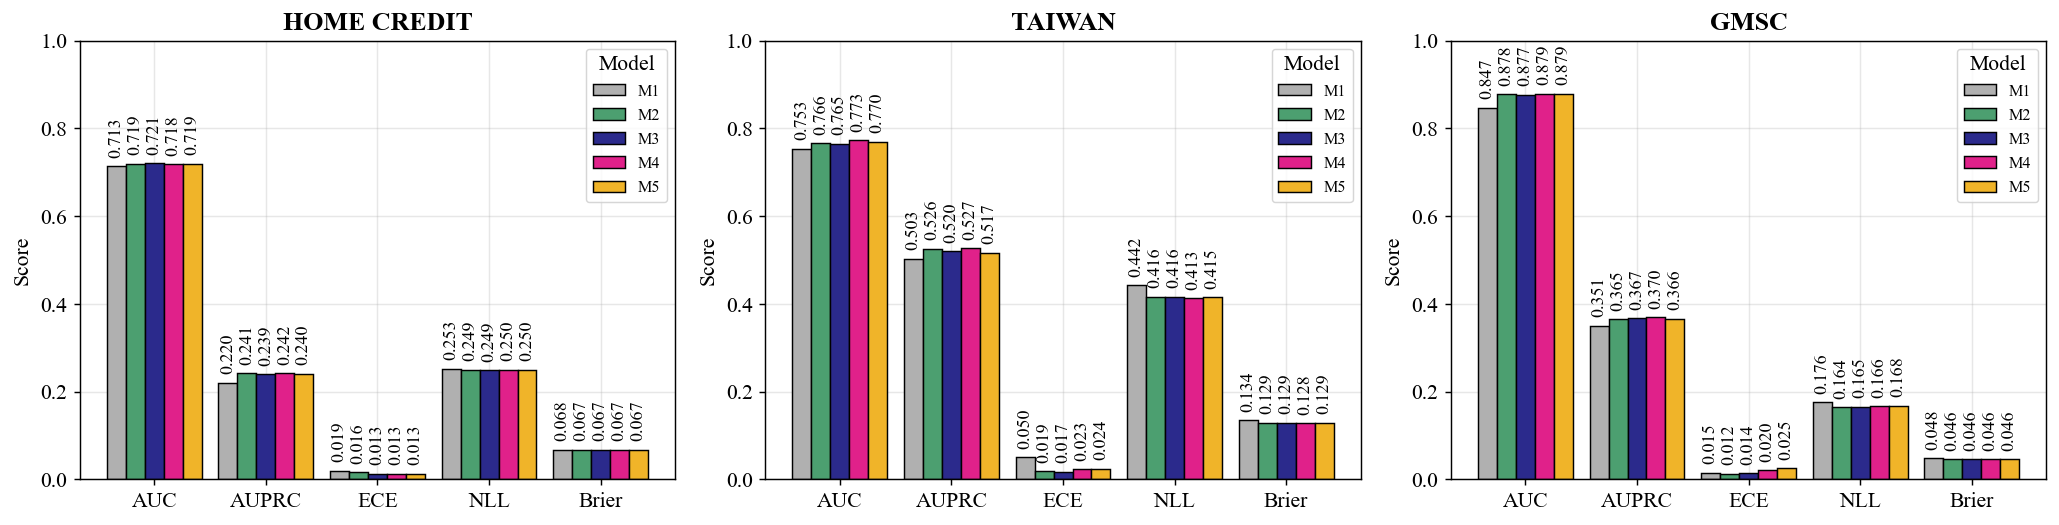

In [19]:
metrics = ["AUC", "AUPRC", "ECE", "NLL", "Brier"]
bal = table1[table1["Split"] == "natural"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, ds in zip(axes, DATASETS):
    sub = bal[bal["Dataset"] == DATASET_LABELS[ds]]
    x = np.arange(len(metrics))
    width = 0.17
    for i, model in enumerate(ALL_MODELS):
        row = sub[sub["Model"] == model]
        if row.empty:
            continue
        vals = [row[m].values[0] for m in metrics]
        bars = ax.bar(x + i * width, vals, width, label=model, color=MODEL_COLOR[model])
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", va="bottom",
                    fontsize=10, rotation=90)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(metrics)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title="Model", fontsize=9)

fig.tight_layout()
save(fig, "fig1_model_performance")


## 3. Fig 2 — faithfulness curves (prob variant)


--- Tên biểu đồ: fig2_faithfulness_curves ---
Đã lưu tại: ../result/figure/fig2_faithfulness_curves.png


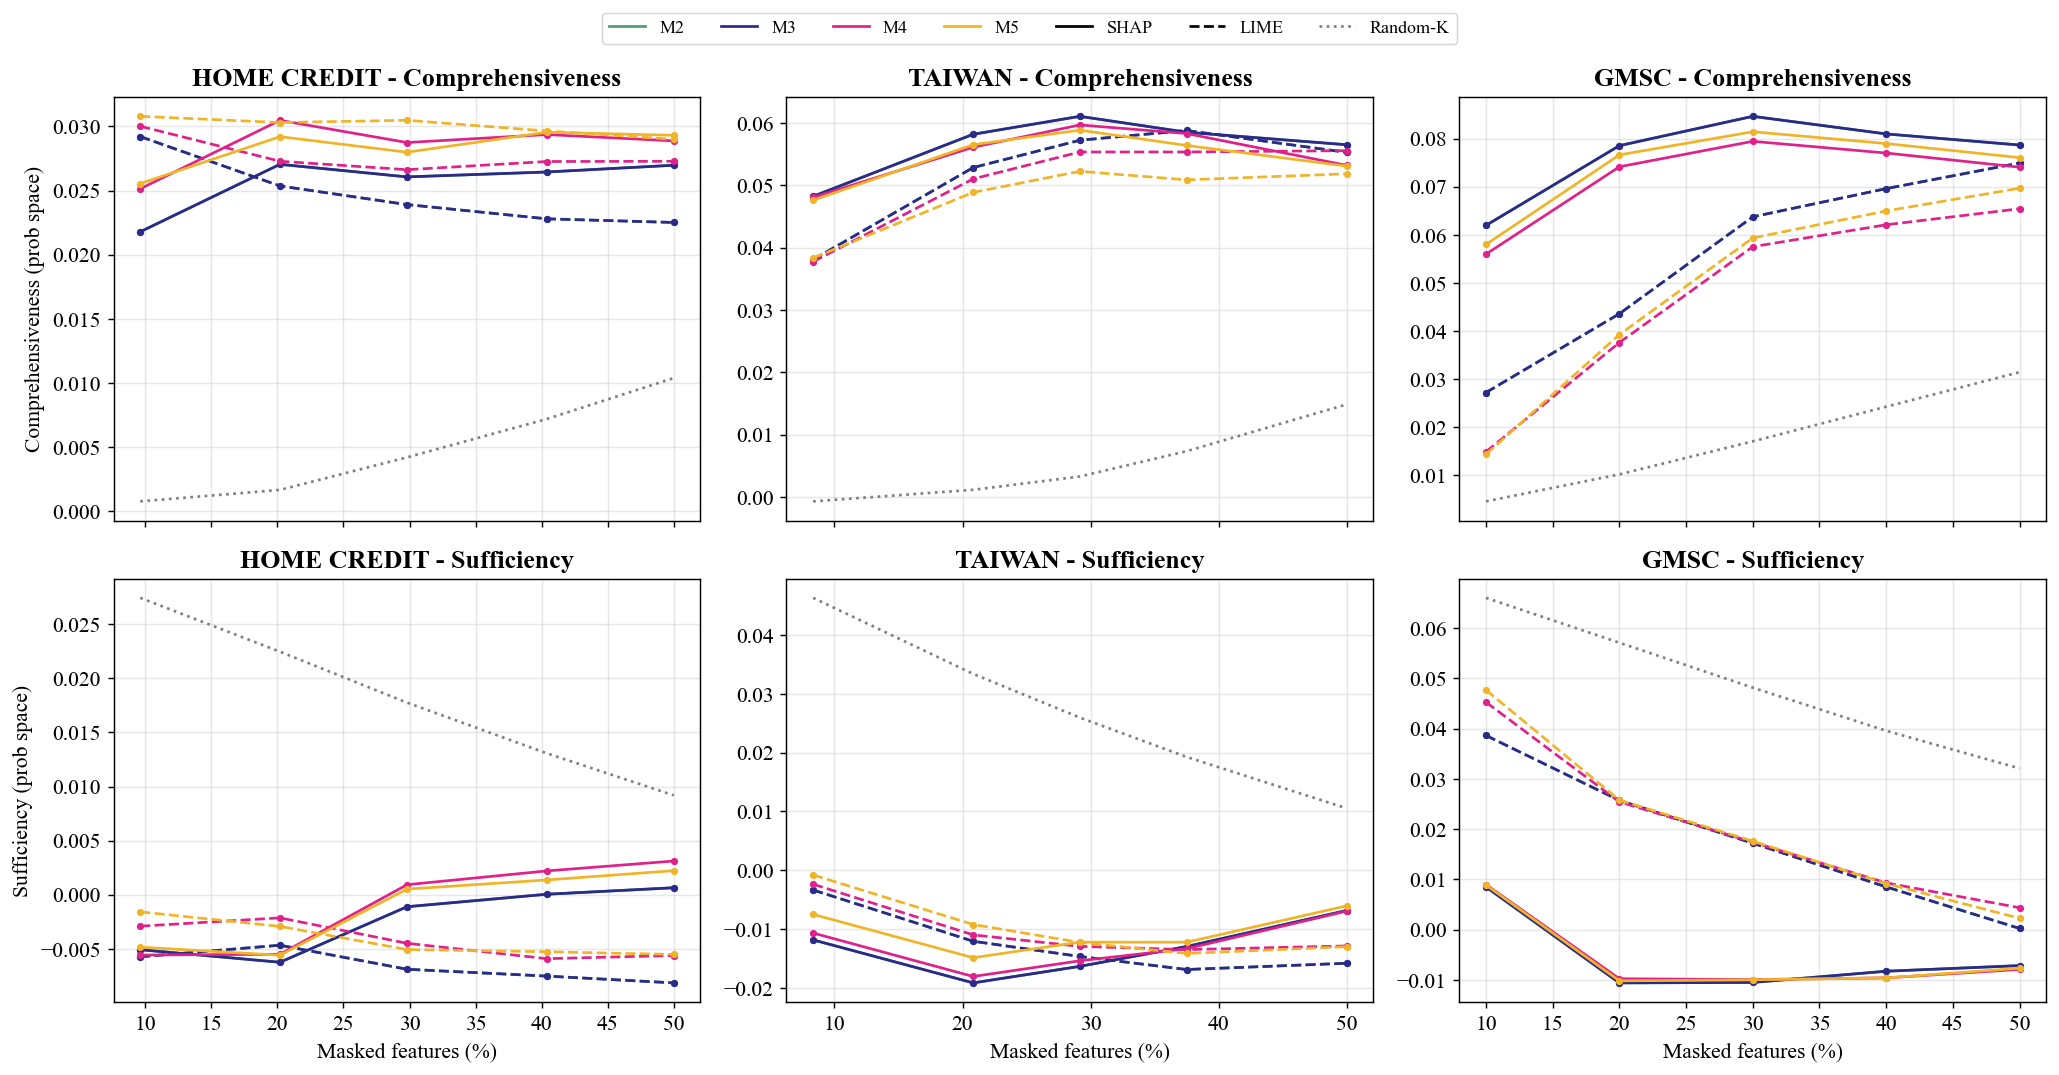

In [20]:
prob2 = table2[table2["Variant"] == "prob"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex="col")
for col, ds in enumerate(DATASETS):
    sub = prob2[prob2["Dataset"] == DATASET_LABELS[ds]]
    ax_comp = axes[0, col]
    ax_suff = axes[1, col]
    if sub.empty:
        ax_comp.set_title(f"{DATASET_LABELS[ds]} - Comprehensiveness", fontweight="bold")
        ax_suff.set_title(f"{DATASET_LABELS[ds]} - Sufficiency", fontweight="bold")
        continue

    # The K grid is guaranteed (by NB5/NB2's get_k_vals) to sit at exactly 10/20/30/40/50% of
    # n_features, so n_features can be recovered from the grid itself instead of being
    # hard-coded per dataset -- the largest K in the grid IS the 50% point.
    n_features = round(sub["K"].max() / 0.5)

    for model in UQ_MODELS:
        for method, ls in [("SHAP", "-"), ("LIME", "--")]:
            m = sub[(sub["Model"] == model) & (sub["Method"] == method)].sort_values("K")
            if m.empty:
                continue
            k_pct = m["K"] / n_features * 100
            ax_comp.plot(k_pct, m["Comp"], ls, color=MODEL_COLOR[model], marker="o", markersize=3)
            ax_suff.plot(k_pct, m["Suff"], ls, color=MODEL_COLOR[model], marker="o", markersize=3)
    rand = sub[(sub["Model"] == "M5") & (sub["Method"] == "SHAP")].sort_values("K")
    if not rand.empty:
        rand_pct = rand["K"] / n_features * 100
        ax_comp.plot(rand_pct, rand["CompRandom"], ":", color="gray", label="Random-K")
        ax_suff.plot(rand_pct, rand["SuffRandom"], ":", color="gray", label="Random-K")

    ax_comp.set_title(f"{DATASET_LABELS[ds]} - Comprehensiveness", fontweight="bold")
    ax_suff.set_title(f"{DATASET_LABELS[ds]} - Sufficiency", fontweight="bold")
    ax_suff.set_xlabel("Masked features (%)")
    if col == 0:
        ax_comp.set_ylabel("Comprehensiveness (prob space)")
        ax_suff.set_ylabel("Sufficiency (prob space)")

from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], color=MODEL_COLOR[m], label=m) for m in UQ_MODELS]
legend_elems += [Line2D([0], [0], color="black", linestyle="-", label="SHAP"),
                 Line2D([0], [0], color="black", linestyle="--", label="LIME"),
                 Line2D([0], [0], color="gray", linestyle=":", label="Random-K")]
fig.legend(handles=legend_elems, loc="upper center", ncol=7, bbox_to_anchor=(0.5, 1.04), fontsize=10)
fig.tight_layout()
from IPython.display import display
save(fig, "fig2_faithfulness_curves")

## 4. Fig 3 — HB-MCD uncertainty decomposition


--- Tên biểu đồ: fig3_uq_decomposition ---
Đã lưu tại: ../result/figure/fig3_uq_decomposition.png


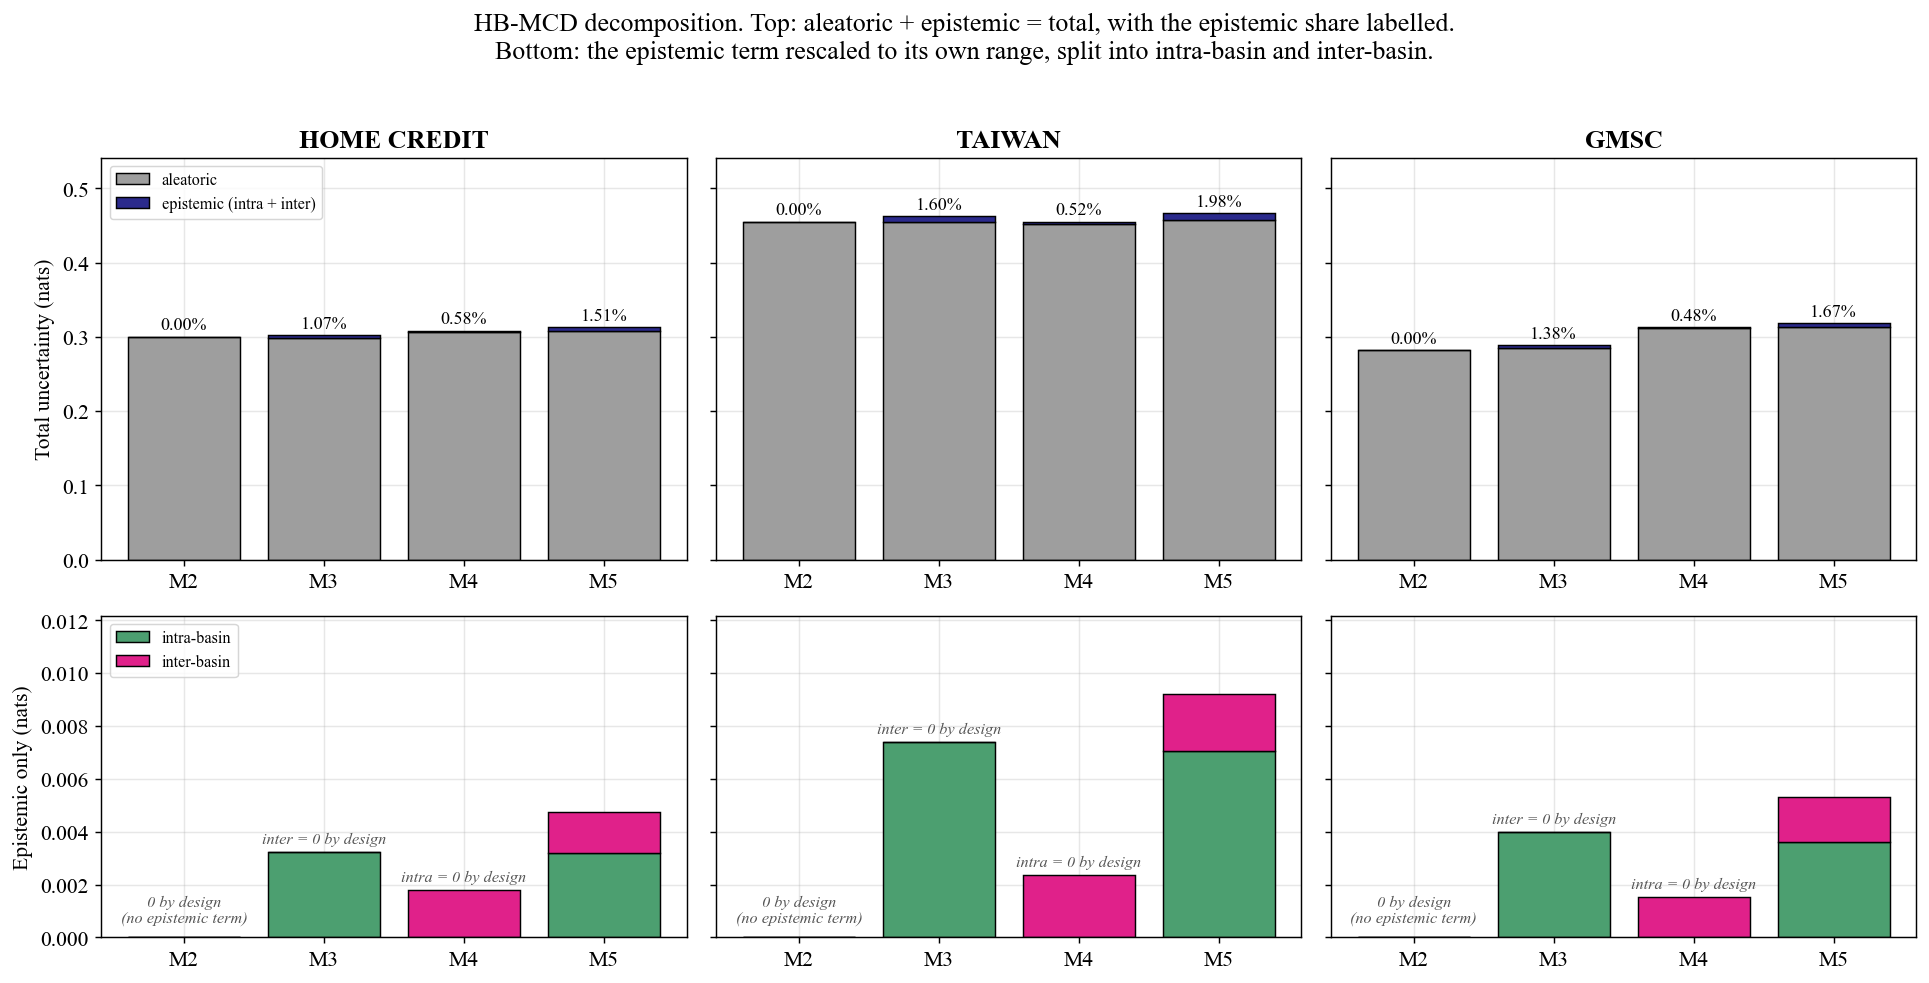

In [21]:
# Fig 3 - HB-MCD decomposition, two rows on two scales.
# The epistemic share is 0.58-2.24% of total uncertainty, so a single stacked
# axis renders the intra/inter segments invisible. The top row keeps additivity
# (aleatoric + epistemic = total) and makes that small share itself readable;
# the bottom row rescales to the epistemic range so the intra/inter split, and
# the two structural zeros, become legible.
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), sharey="row",
                         gridspec_kw={"height_ratios": [1.25, 1.0]})

def _val(sub, model, comp):
    row = sub[(sub["Model"] == model) & (sub["Component"] == comp)]["Mean"]
    return float(row.values[0]) if len(row) else 0.0

# Both rows share their y-axis across datasets so the panels stay comparable,
# so the limits must come from the maximum over ALL datasets, not per panel.
VALS = {}
for ds in DATASETS:
    sub = table6[table6["Dataset"] == DATASET_LABELS[ds]]
    VALS[ds] = (
        np.array([_val(sub, m, "aleatoric") for m in UQ_MODELS]),
        np.array([_val(sub, m, "intra") for m in UQ_MODELS]),
        np.array([_val(sub, m, "inter") for m in UQ_MODELS]),
    )
TOP_MAX = max((a + i + j).max() for a, i, j in VALS.values())
BOT_MAX = max((i + j).max() for a, i, j in VALS.values())

for col, ds in enumerate(DATASETS):
    x = np.arange(len(UQ_MODELS))
    alea, intra, inter = VALS[ds]
    epis = intra + inter

    # ---- top row: total = aleatoric + epistemic ------------------------------
    ax = axes[0, col]
    ax.bar(x, alea, color=COMPONENT_COLOR["aleatoric"], label="aleatoric")
    ax.bar(x, epis, bottom=alea, color=COMPONENT_COLOR["epistemic"],
           label="epistemic (intra + inter)")
    for xi, (a, e) in enumerate(zip(alea, epis)):
        share = 100.0 * e / (a + e) if (a + e) > 0 else 0.0
        ax.annotate(f"{share:.2f}%", (xi, a + e), textcoords="offset points",
                    xytext=(0, 4), ha="center", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(UQ_MODELS)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_ylim(0, TOP_MAX * 1.16)
    if col == 0:
        ax.set_ylabel("Total uncertainty (nats)")
    # đặt ở panel đầu vì vùng trên của panel đó trống, không đè lên cột nào
    if col == 0:
        ax.legend(fontsize=9, loc="upper left")

    # ---- bottom row: epistemic only, its own scale ---------------------------
    ax = axes[1, col]
    ax.bar(x, intra, color=COMPONENT_COLOR["intra"], label="intra-basin")
    ax.bar(x, inter, bottom=intra, color=COMPONENT_COLOR["inter"],
           label="inter-basin")
    for xi, m in enumerate(UQ_MODELS):
        if epis[xi] <= 0:
            ax.annotate("0 by design\n(no epistemic term)", (xi, 0),
                        textcoords="offset points", xytext=(0, 8), ha="center",
                        fontsize=9, style="italic", color="#555555")
        else:
            miss = "intra = 0 by design" if intra[xi] <= 0 else (
                   "inter = 0 by design" if inter[xi] <= 0 else "")
            if miss:
                ax.annotate(miss, (xi, epis[xi]), textcoords="offset points",
                            xytext=(0, 5), ha="center", fontsize=9,
                            style="italic", color="#555555")
    ax.set_xticks(x)
    ax.set_xticklabels(UQ_MODELS)
    ax.set_ylim(0, BOT_MAX * 1.32)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    if col == 0:
        ax.set_ylabel("Epistemic only (nats)")
    if col == 0:
        ax.legend(fontsize=9, loc="upper left")

fig.suptitle("HB-MCD decomposition. Top: aleatoric + epistemic = total, with the "
             "epistemic share labelled.\nBottom: the epistemic term rescaled to its "
             "own range, split into intra-basin and inter-basin.", y=1.02)
fig.tight_layout()
save(fig, "fig3_uq_decomposition")


## 5. Fig 4 — Spearman: epistemic vs aleatoric (raw, negative control)


--- Tên biểu đồ: fig4_spearman_components ---
Đã lưu tại: ../result/figure/fig4_spearman_components.png


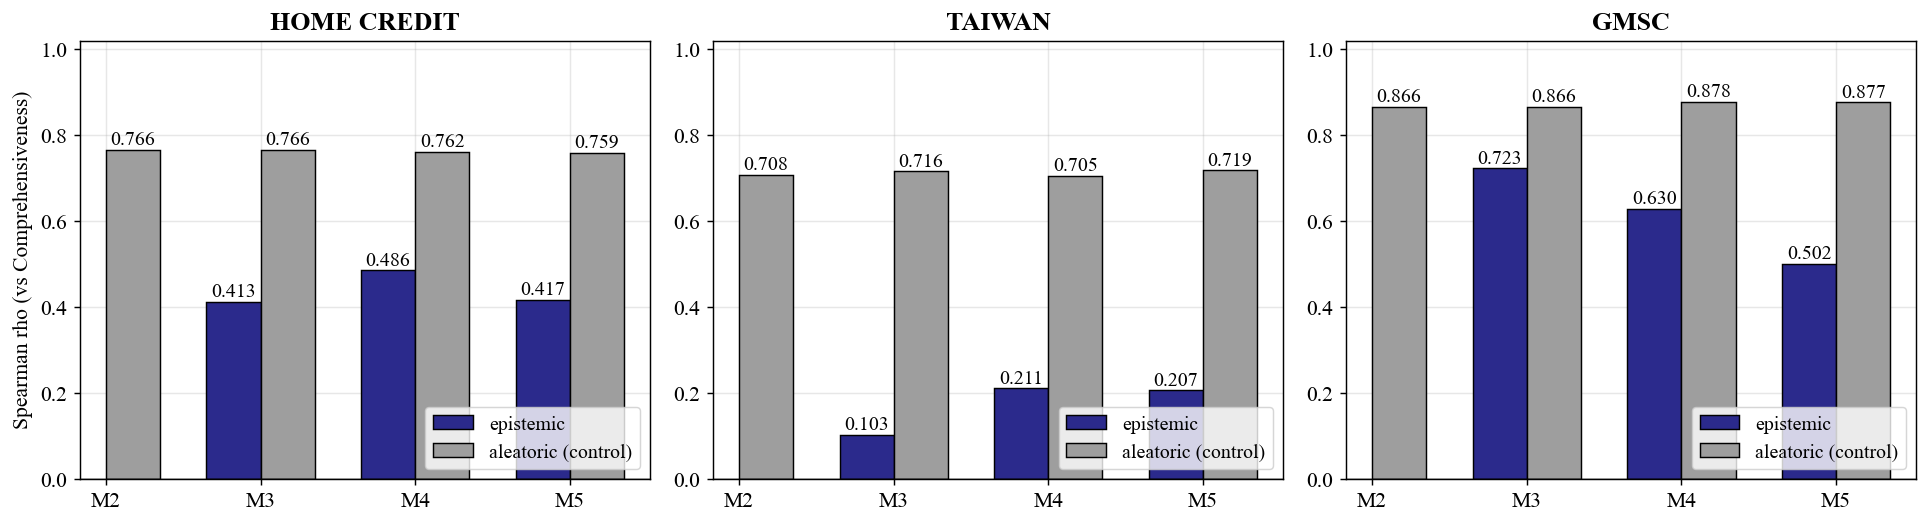

In [22]:
all3 = table3[table3["Group"] == "All"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, ds in zip(axes, DATASETS):
    sub = all3[(all3["Dataset"] == DATASET_LABELS[ds]) & (all3["Method"] == "SHAP")]
    x = np.arange(len(UQ_MODELS))
    width = 0.35
    epi_vals = [sub[sub["Model"] == m]["rho_epistemic"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in UQ_MODELS]
    ale_vals = [sub[sub["Model"] == m]["rho_aleatoric"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in UQ_MODELS]
    bars_epi = ax.bar(x - width / 2, epi_vals, width, label="epistemic", color="#2B2A8C")
    bars_ale = ax.bar(x + width / 2, ale_vals, width, label="aleatoric (control)", color="#9E9E9E")
    ax.bar_label(bars_epi, fmt='%.3f', padding=0.5, rotation=0, fontsize=11)
    ax.bar_label(bars_ale, fmt='%.3f', padding=0.5, rotation=0, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(UQ_MODELS)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(0,1.02)

    if ds == "home_credit":
        ax.set_ylabel("Spearman rho (vs Comprehensiveness)")
    ax.legend(fontsize=11, loc = "lower right")

fig.tight_layout()
save(fig, "fig4_spearman_components")


## 6. Fig 5 — partial correlation confound check


--- Tên biểu đồ: fig5_partial_correlation_confound_check ---
Đã lưu tại: ../result/figure/fig5_partial_correlation_confound_check.png


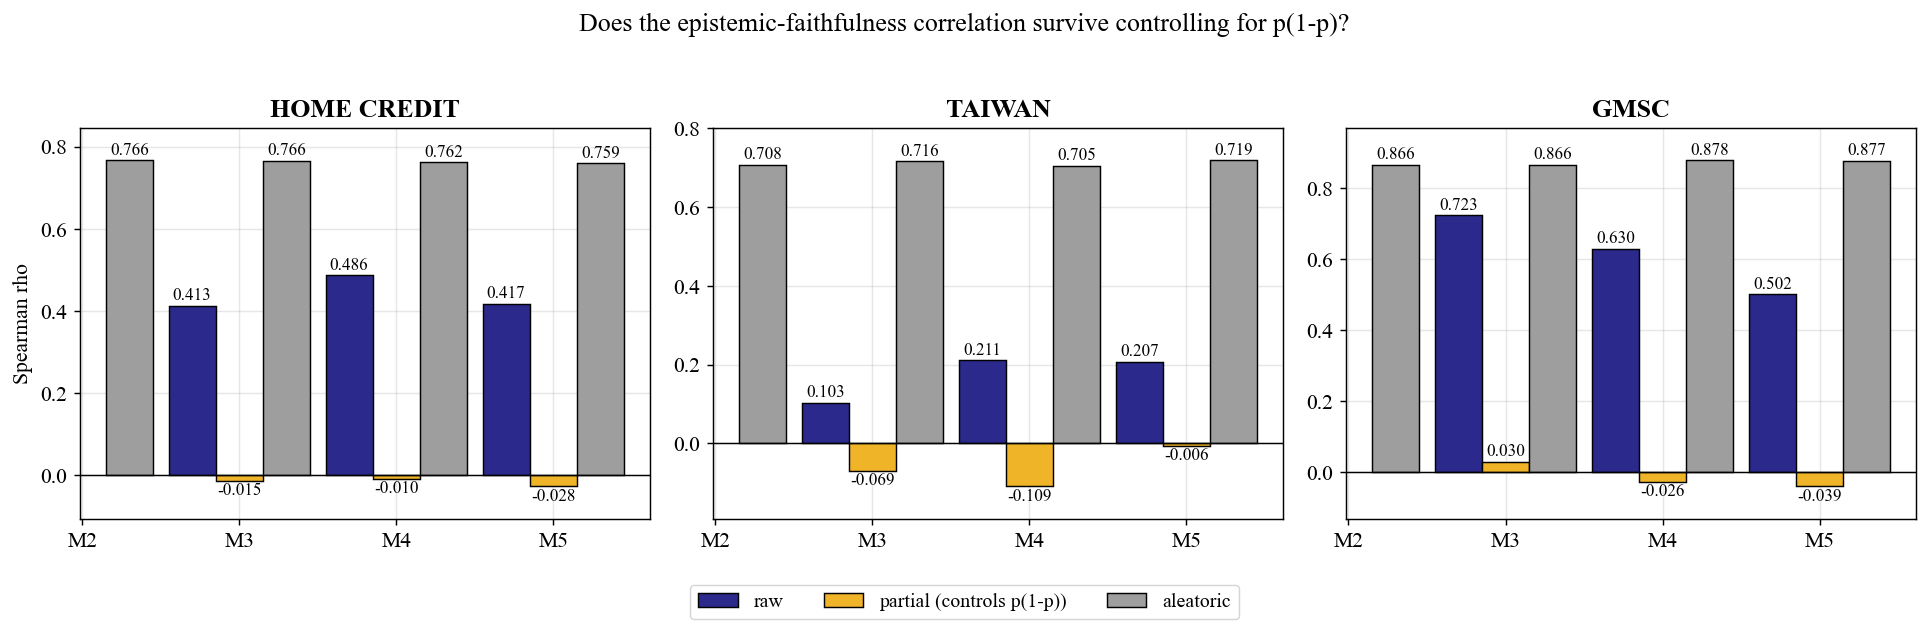

In [23]:
prob7 = table7[(table7["Variant"] == "prob") & (table7["Method"] == "SHAP")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, ds in zip(axes, DATASETS):
    sub = prob7[prob7["Dataset"] == DATASET_LABELS[ds]]
    x = np.arange(len(UQ_MODELS))
    width = 0.30
    raw = [sub[sub["Model"] == m]["rho_raw"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in UQ_MODELS]
    par = [sub[sub["Model"] == m]["rho_partial"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in UQ_MODELS]
    ale = [sub[sub["Model"] == m]["rho_aleatoric"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in UQ_MODELS]
    bars_raw = ax.bar(x - width, raw, width, label="raw", color="#2B2A8C")
    bars_par = ax.bar(x, par, width, label="partial (controls p(1-p))", color="#F0B429")
    bars_ale = ax.bar(x + width, ale, width, label="aleatoric", color="#9E9E9E")
    ax.bar_label(bars_raw, fmt='%.3f', padding=1, rotation=0, fontsize=9.5)
    ax.bar_label(bars_par, fmt='%.3f', padding=1, rotation=0, fontsize=9.5)
    ax.bar_label(bars_ale, fmt='%.3f', padding=1, rotation=0, fontsize=9.5)
    ax.margins(y=0.1) 
    ax.set_xticks(x)
    ax.set_xticklabels(UQ_MODELS)

    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    if ds == "home_credit":
        ax.set_ylabel("Spearman rho")

fig.suptitle("Does the epistemic-faithfulness correlation survive controlling for p(1-p)?", y=1.03)
fig.tight_layout()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3, fontsize=11)
save(fig, "fig5_partial_correlation_confound_check")


## 7. Fig 6 — minority vs majority (dumbbell)


--- Tên biểu đồ: fig6_minority_majority_forest ---
Đã lưu tại: ../result/figure/fig6_minority_majority_forest.png


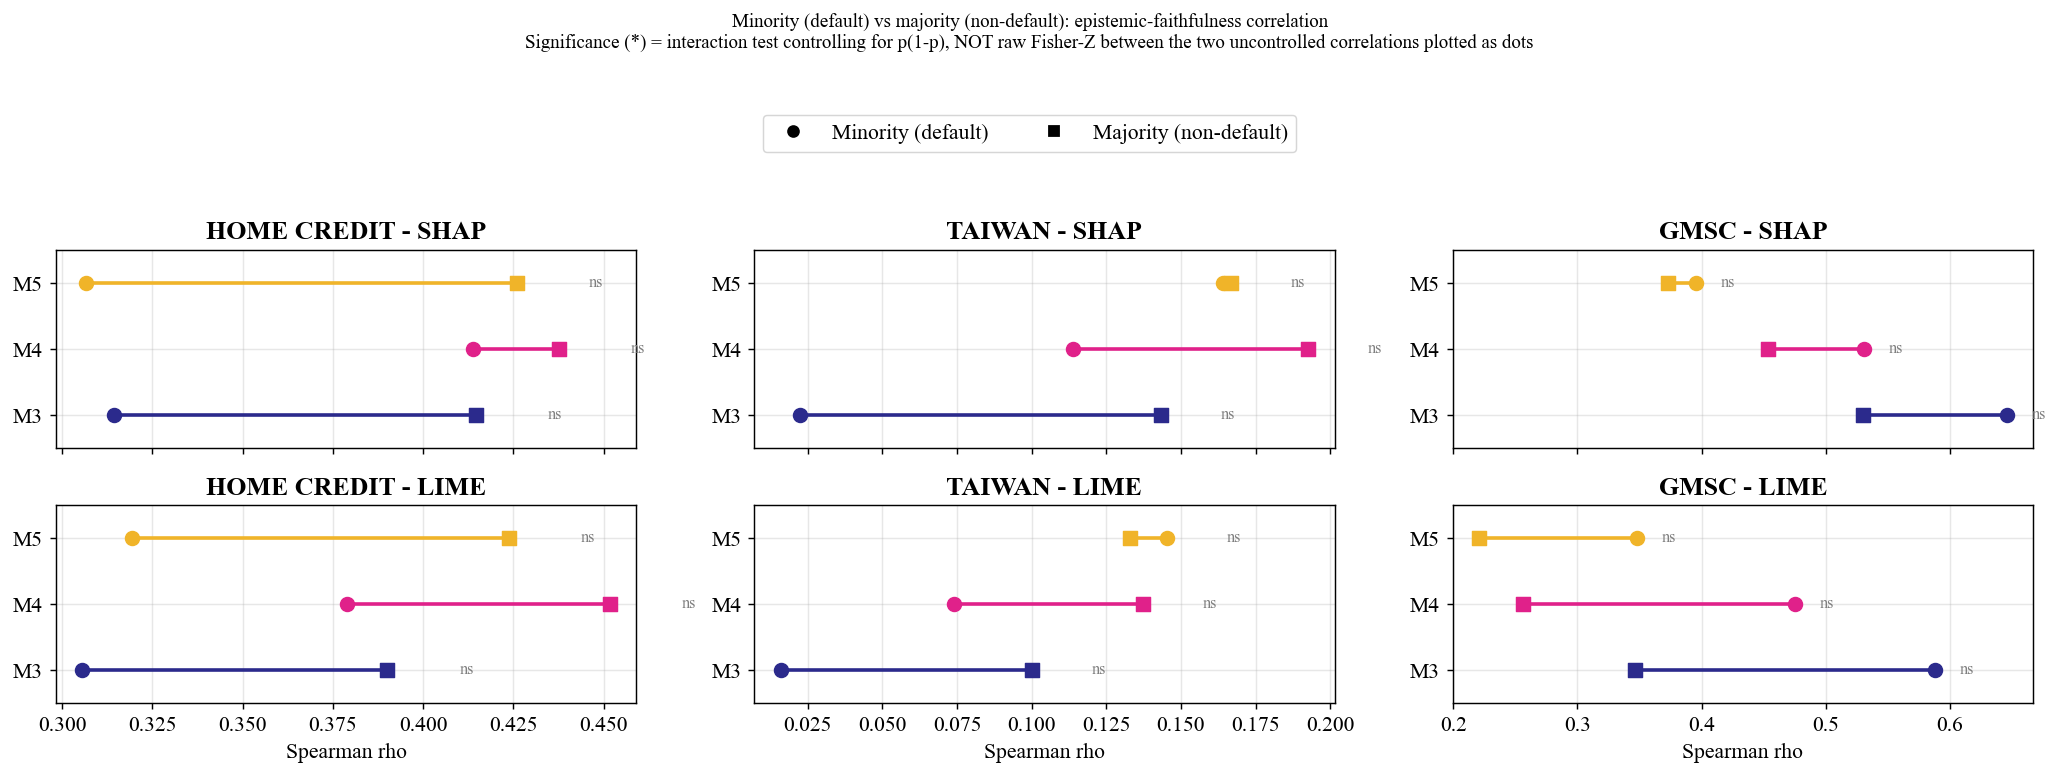

In [24]:
SIG_COL = "interaction_Sig_FDR" if "interaction_Sig_FDR" in table3b.columns else "Sig_FDR"
if SIG_COL != "interaction_Sig_FDR":
    print("[fig6] interaction_Sig_FDR not found in table3b -- falling back to the raw, "
          "uncontrolled Fisher-Z Sig_FDR (old NB6 schema; re-run NB6 for the q-controlled test).")

fig, axes = plt.subplots(2, 3, figsize=(16, 5), sharex="col")
plot_models = ["M3", "M4", "M5"]
for col, ds in enumerate(DATASETS):
    for row_i, method in enumerate(["SHAP", "LIME"]):
        ax = axes[row_i, col]
        sub = table3b[(table3b["Dataset"] == DATASET_LABELS[ds]) & (table3b["Method"] == method)]
        for i, model in enumerate(plot_models):
            r = sub[sub["Model"] == model]
            if r.empty:
                continue
            rmin, rmaj = r["rho_minority"].values[0], r["rho_majority"].values[0]
            sig = bool(r[SIG_COL].values[0]) if SIG_COL in r.columns else False
            ax.plot([rmin, rmaj], [i, i], color=MODEL_COLOR[model], linewidth=2, zorder=1)
            ax.scatter([rmin], [i], marker="o", color=MODEL_COLOR[model], s=60, zorder=2)
            ax.scatter([rmaj], [i], marker="s", color=MODEL_COLOR[model], s=60, zorder=2)
            label = "*" if sig else "ns"
            ax.text(max(rmin, rmaj) + 0.02, i, label, va="center",
                    color="red" if sig else "gray", fontsize=9)
            ax.set_ylim(-0.5, len(plot_models) - 0.5)

        ax.set_yticks(range(len(plot_models)))
        ax.set_yticklabels(plot_models)
        ax.set_title(f"{DATASET_LABELS[ds]} - {method}", fontweight="bold")
        if row_i == 1:
            ax.set_xlabel("Spearman rho")

fig.suptitle("Minority (default) vs majority (non-default): epistemic-faithfulness correlation\n"
             "Significance (*) = interaction test controlling for p(1-p), NOT raw Fisher-Z "
             "between the two uncontrolled correlations plotted as dots", y=1.19, fontsize=10.5)

from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], marker="o", color="black", linestyle="", label="Minority (default)"),
                Line2D([0], [0], marker="s", color="black", linestyle="", label="Majority (non-default)")]
fig.legend(handles=legend_elems, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
save(fig, "fig6_minority_majority_forest")

## 8. Fig 7 — budget grid frontier (RQ3)


--- Tên biểu đồ: fig7_budget_grid_frontier ---
Đã lưu tại: ../result/figure/fig7_budget_grid_frontier.png


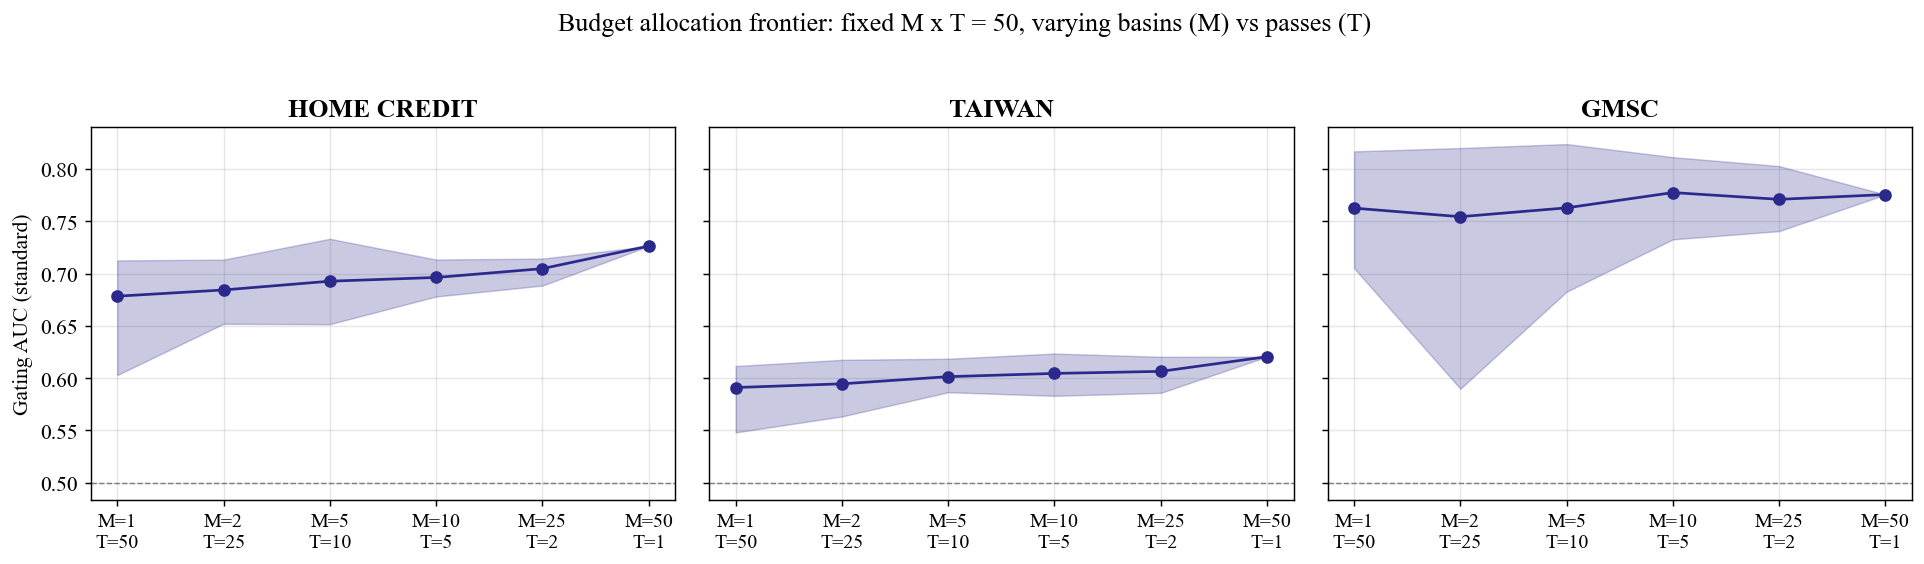

In [25]:
if len(table5):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
    for ax, ds in zip(axes, DATASETS):
        sub = table5[(table5["dataset"] == DATASET_LABELS[ds]) & (table5["metric"] == "gating_auc_std")]
        sub = sub.sort_values("M")
        x = np.arange(len(sub))
        ax.plot(x, sub["mean"], "o-", color="#2B2A8C")
        ax.fill_between(x, sub["ci_low"], sub["ci_high"], alpha=0.25, color="#2B2A8C")
        ax.set_xticks(x)
        ax.set_xticklabels([f"M={m}\nT={t}" for m, t in zip(sub["M"], sub["T"])], fontsize=11)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
        ax.set_title(DATASET_LABELS[ds], fontweight="bold")
        if ds == "home_credit":
            ax.set_ylabel("Gating AUC (standard)")
    fig.suptitle("Budget allocation frontier: fixed M x T = 50, varying basins (M) vs passes (T)", y=1.03)
    fig.tight_layout()
    save(fig, "fig7_budget_grid_frontier")
else:
    print("table5 empty -- skipping fig7 (NB4 outputs not found).")


## 9. Fig 8 — metric consistency across faithfulness variants (RQ4)


--- Tên biểu đồ: fig8_metric_consistency ---
Đã lưu tại: ../result/figure/fig8_metric_consistency.png


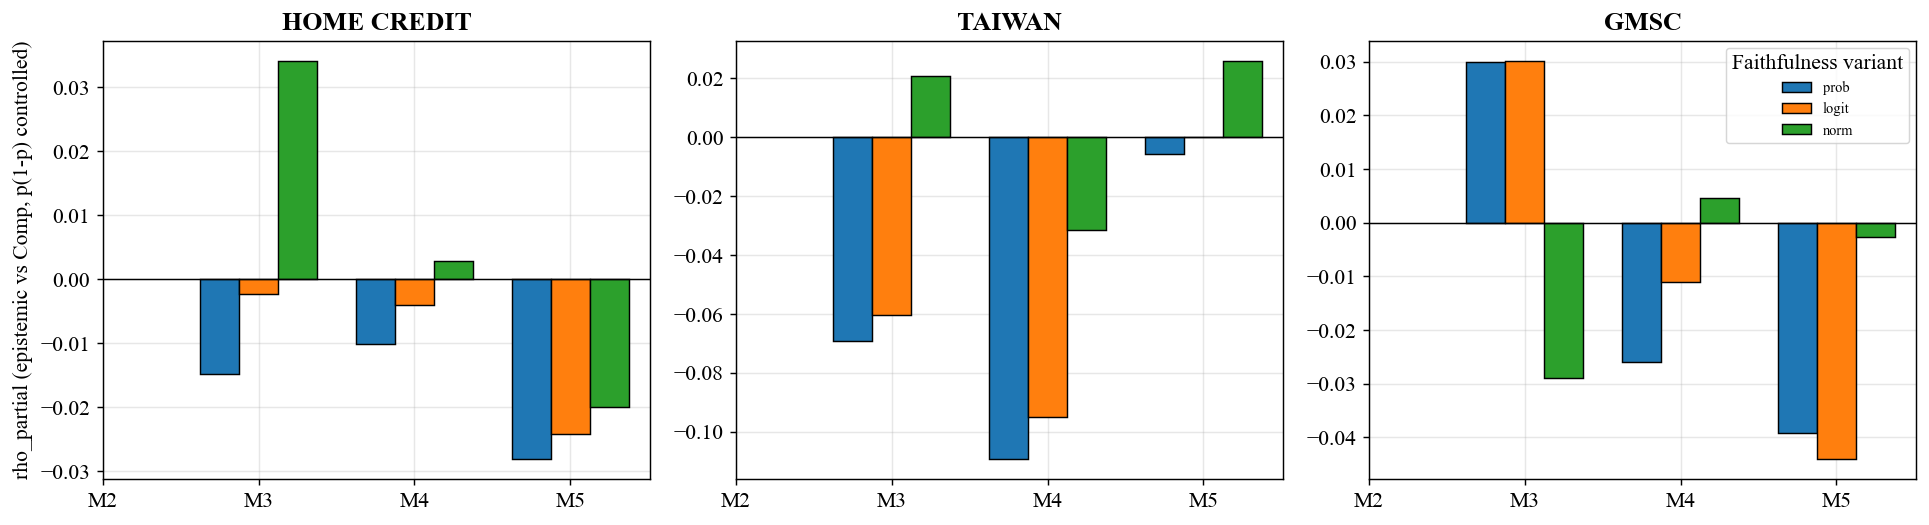

In [26]:
shap7 = table7[table7["Method"] == "SHAP"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, ds in zip(axes, DATASETS):
    sub = shap7[shap7["Dataset"] == DATASET_LABELS[ds]]
    x = np.arange(len(UQ_MODELS))
    width = 0.25
    for i, variant in enumerate(["prob", "logit", "norm"]):
        vals = [
            sub[(sub["Model"] == m) & (sub["Variant"] == variant)]["rho_partial"].values[0]
            if not sub[(sub["Model"] == m) & (sub["Variant"] == variant)].empty else np.nan
            for m in UQ_MODELS
        ]
        ax.bar(x + (i - 1) * width, vals, width, label=variant)
    ax.set_xticks(x)
    ax.set_xticklabels(UQ_MODELS)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    if ds == "home_credit":
        ax.set_ylabel("rho_partial (epistemic vs Comp, p(1-p) controlled)")
    if ds == "gmsc":
        ax.legend(title="Faithfulness variant", fontsize=8)

fig.tight_layout()
save(fig, "fig8_metric_consistency")


## 10. Fig 9 — gating ROC curves


--- Tên biểu đồ: fig9_gating_roc ---
Đã lưu tại: ../result/figure/fig9_gating_roc.png


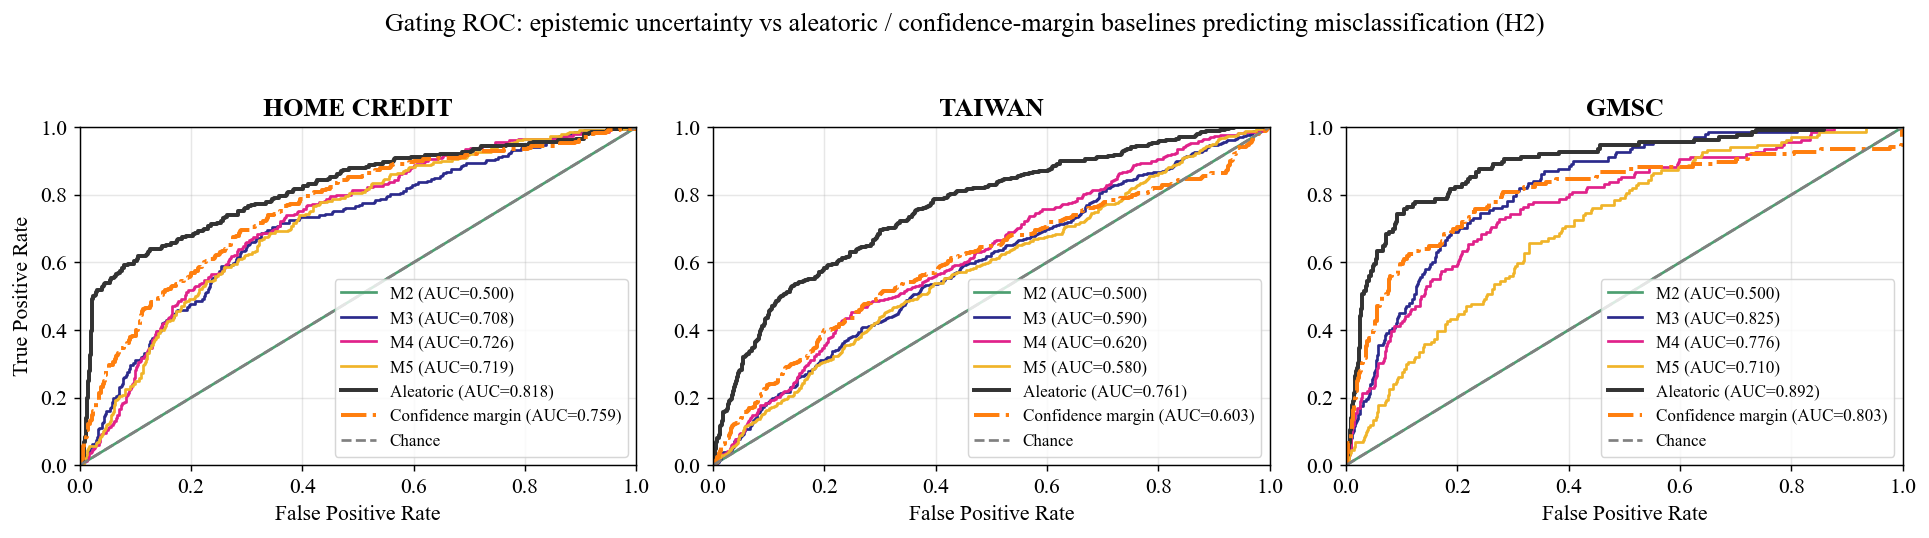

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ds in zip(axes, DATASETS):
    for model in UQ_MODELS:
        path = f"{RAW_NB3_DIR}/{model.lower()}_uncertainty_natural_{ds}.csv"
        if not os.path.exists(path):
            print(f"  [MISSING] {path}")
            continue
        unc = pd.read_csv(path)
        tau, misclassified = gating_labels(unc)

        if misclassified.sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(misclassified, unc["epistemic_unc"])
        auc_val = roc_auc_score(misclassified, unc["epistemic_unc"])
        ax.plot(fpr, tpr, color=MODEL_COLOR[model], label=f"{model} (AUC={auc_val:.3f})")

    # v7 addition (H2): two UQ-free/cheap baselines, computed ONCE per dataset (not per model
    # -- they don't depend on the UQ method, only on the base point prediction/threshold).
    base_unc = None
    for cand in BASELINE_MODEL_CANDIDATES:
        cand_path = f"{RAW_NB3_DIR}/{cand.lower()}_uncertainty_natural_{ds}.csv"
        if os.path.exists(cand_path):
            base_unc = pd.read_csv(cand_path)
            break
    if base_unc is None:
        print(f"  [MISSING] no uncertainty file found for any of {BASELINE_MODEL_CANDIDATES} "
              f"({ds}) -- skipping aleatoric/margin baselines.")
    else:
        b_tau, b_misclassified = gating_labels(base_unc)
        if b_misclassified.sum() > 0:
            fpr_a, tpr_a, _ = roc_curve(b_misclassified, base_unc["aleatoric_unc"])
            auc_a = roc_auc_score(b_misclassified, base_unc["aleatoric_unc"])
            ax.plot(fpr_a, tpr_a, color="#333333", linewidth=2.2,
                    label=f"Aleatoric (AUC={auc_a:.3f})")

            margin = -np.abs(base_unc["pred_mean"] - b_tau)
            fpr_m, tpr_m, _ = roc_curve(b_misclassified, margin)
            auc_m = roc_auc_score(b_misclassified, margin)
            ax.plot(fpr_m, tpr_m, color="#FF7F0E", linewidth=2.2, linestyle="-.",
                    label=f"Confidence margin (AUC={auc_m:.3f})")

    ax.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    if ds == "home_credit":
        ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=9.5, loc = "lower right")

fig.suptitle("Gating ROC: epistemic uncertainty vs aleatoric / confidence-margin baselines "
             "predicting misclassification (H2)", y=1.03)
fig.tight_layout()
save(fig, "fig9_gating_roc")

## 11. Fig 10 — stability


--- Tên biểu đồ: fig10_stability ---
Đã lưu tại: ../result/figure/fig10_stability.png


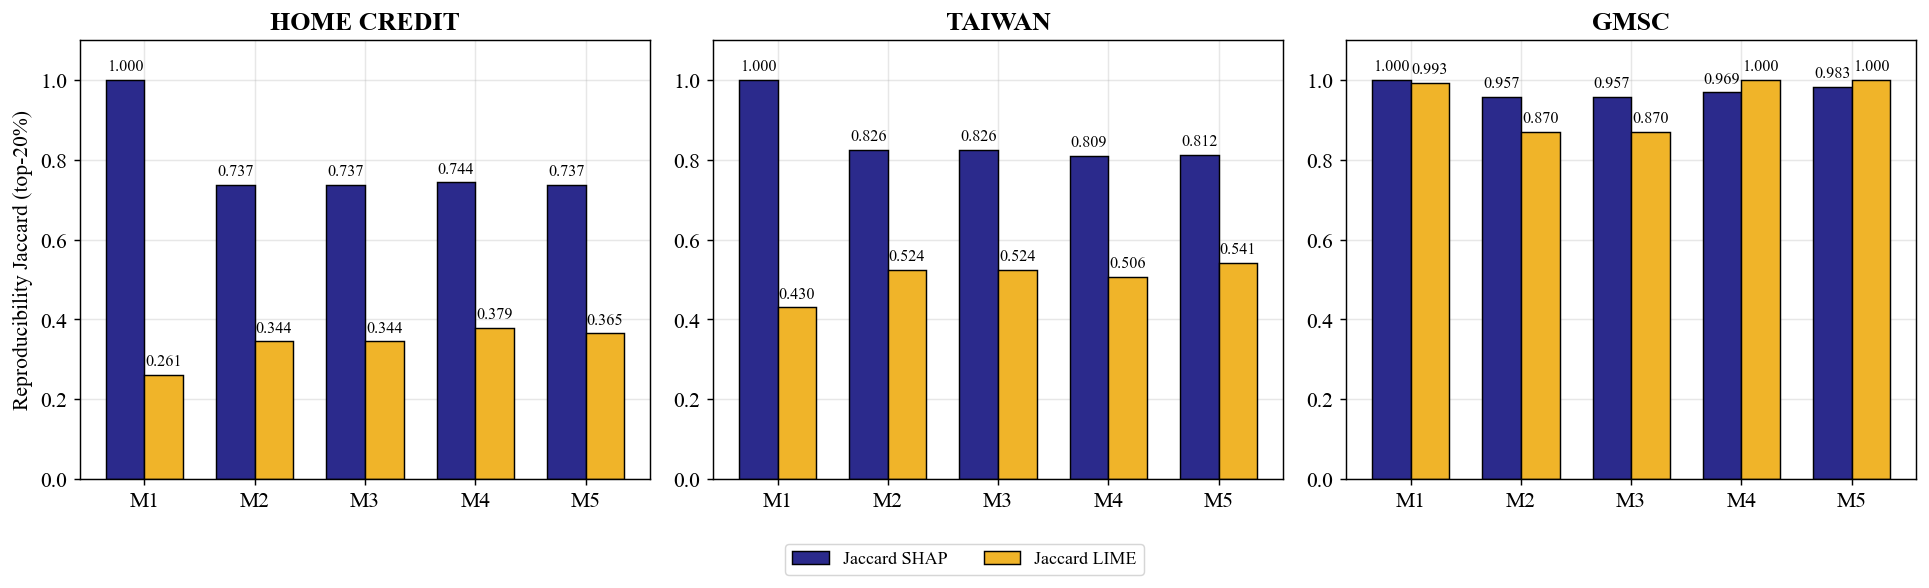

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, ds in zip(axes, DATASETS):
    sub = table2b[table2b["Dataset"] == DATASET_LABELS[ds]]
    x = np.arange(len(ALL_MODELS))
    width = 0.35
    jac_shap = [sub[sub["Model"] == m]["Jaccard_SHAP"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in ALL_MODELS]
    jac_lime = [sub[sub["Model"] == m]["Jaccard_LIME"].values[0] if not sub[sub["Model"] == m].empty else np.nan for m in ALL_MODELS]
    
    # 1. Gán kết quả vào biến để gọi hàm dán nhãn
    bars_shap = ax.bar(x - width / 2, jac_shap, width, label="Jaccard SHAP", color="#2B2A8C")
    bars_lime = ax.bar(x + width / 2, jac_lime, width, label="Jaccard LIME", color="#F0B429")
    
    # 2. Tự động thêm số trên đỉnh cột
    ax.bar_label(bars_shap, fmt='%.3f', padding=3, rotation=0, fontsize=9)
    ax.bar_label(bars_lime, fmt='%.3f', padding=3, rotation=0, fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(ALL_MODELS)
    
    # 3. Nới trục Y lên 1 chút để đủ không gian hiển thị số nằm dọc
    ax.set_ylim(0, 1.1)
    
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    if ds == "home_credit":
        ax.set_ylabel("Reproducibility Jaccard (top-20%)")

fig.tight_layout()

# 4. Gom legend xuống dưới cùng thành một bảng nằm ngang
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2, fontsize=10)

save(fig, "fig10_stability")



## 12. Fig 11 — USFG heatmap


--- Tên biểu đồ: fig11_usfg_heatmap ---
Đã lưu tại: ../result/figure/fig11_usfg_heatmap.png


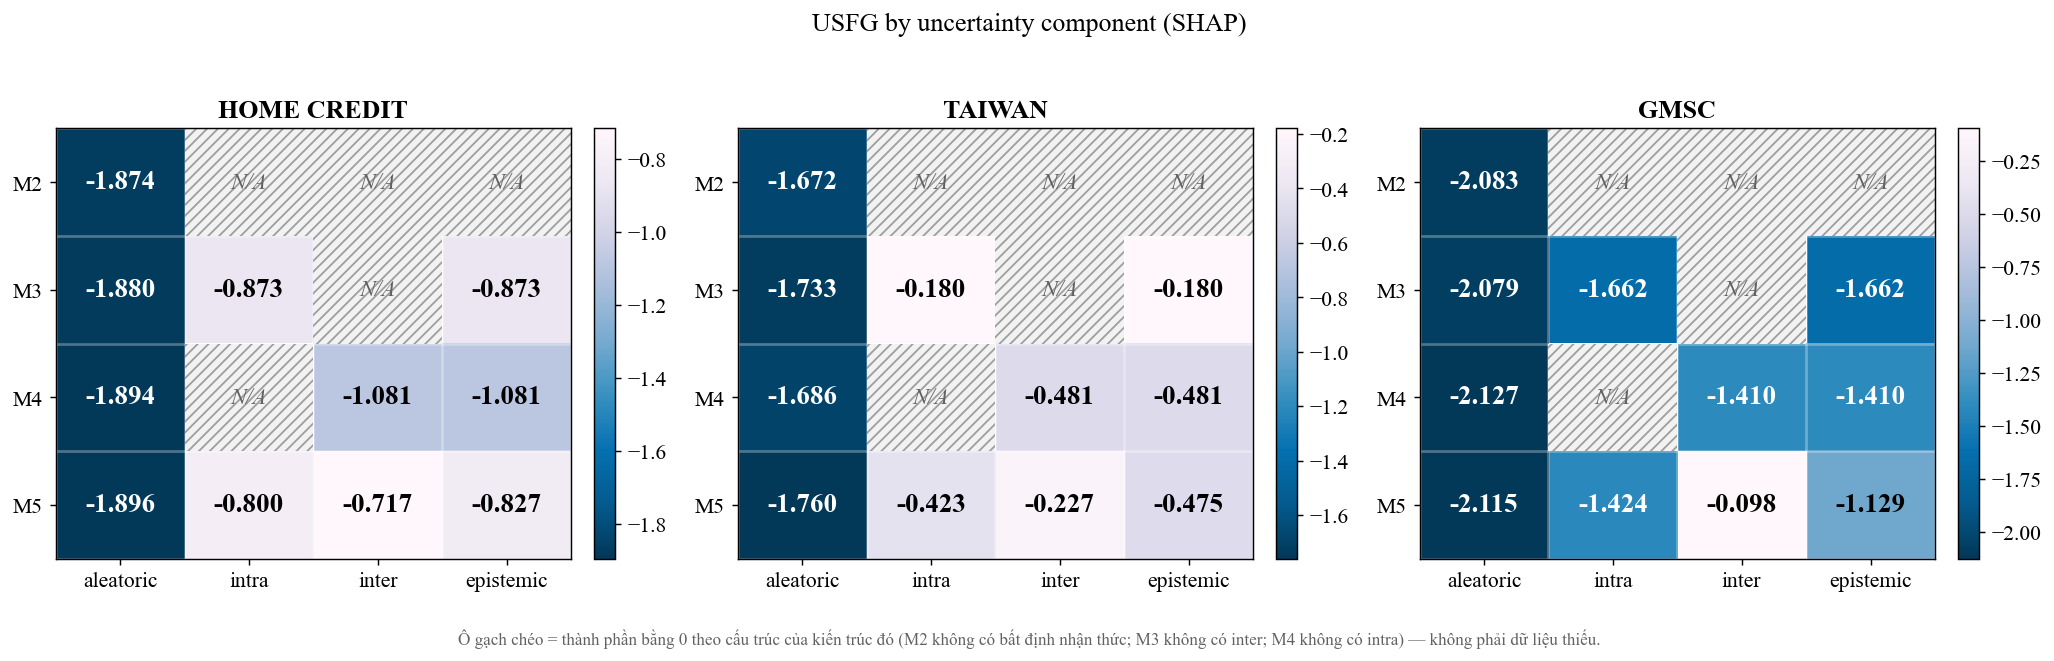

In [29]:
shap9 = table9[table9["Method"] == "SHAP"]
components = ["aleatoric", "intra", "inter", "epistemic"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, ds in zip(axes, DATASETS):
    sub = shap9[shap9["Dataset"] == DATASET_LABELS[ds]]
    mat = np.full((len(UQ_MODELS), len(components)), np.nan)
    for i, model in enumerate(UQ_MODELS):
        for j, comp in enumerate(components):
            r = sub[(sub["Model"] == model) & (sub["Component"] == comp)]
            if not r.empty:
                mat[i, j] = r["USFG"].values[0]
                
    # 1. Đổi bảng màu sang "plasma" y hệt hình mẫu
    im = ax.imshow(mat, cmap="PuBu_r", aspect="auto")
    
    # 2. Tạo viền trắng sắc nét phân cách các ô
    ax.set_xticks(np.arange(mat.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(mat.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.grid(which="major", visible=False) # Tắt lưới mờ mặc định
    
    ax.set_xticks(range(len(components)))
    ax.set_xticklabels(components)
    ax.set_yticks(range(len(UQ_MODELS)))
    ax.set_yticklabels(UQ_MODELS)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    
    # 3. Thêm số với font to, in đậm, màu tự động tương phản
    for i in range(len(UQ_MODELS)):
        for j in range(len(components)):
            if not np.isnan(mat[i, j]):
                # Lấy màu tại ô đó và tính độ sáng (luminance)
                rgba = im.cmap(im.norm(mat[i, j]))
                lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                
                # Nền tối (< 0.6) thì chữ trắng, nền sáng thì chữ đen
                text_color = "white" if lum < 0.6 else "black"
                
                # Chỉnh to fontsize lên 11 và in đậm (fontweight="bold")
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", 
                        color=text_color, fontsize=15, fontweight="bold")
                
    mark_na_cells(ax, mat, fontsize=13)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("USFG by uncertainty component (SHAP)", y=1.03)
fig.tight_layout()
fig.text(0.5, -0.05, NA_FOOTNOTE, ha="center", fontsize=9.5,
         color="#616161")
save(fig, "fig11_usfg_heatmap")



## 13. Fig 12 — risk-coverage curves


--- Tên biểu đồ: fig12_risk_coverage ---
Đã lưu tại: ../result/figure/fig12_risk_coverage.png


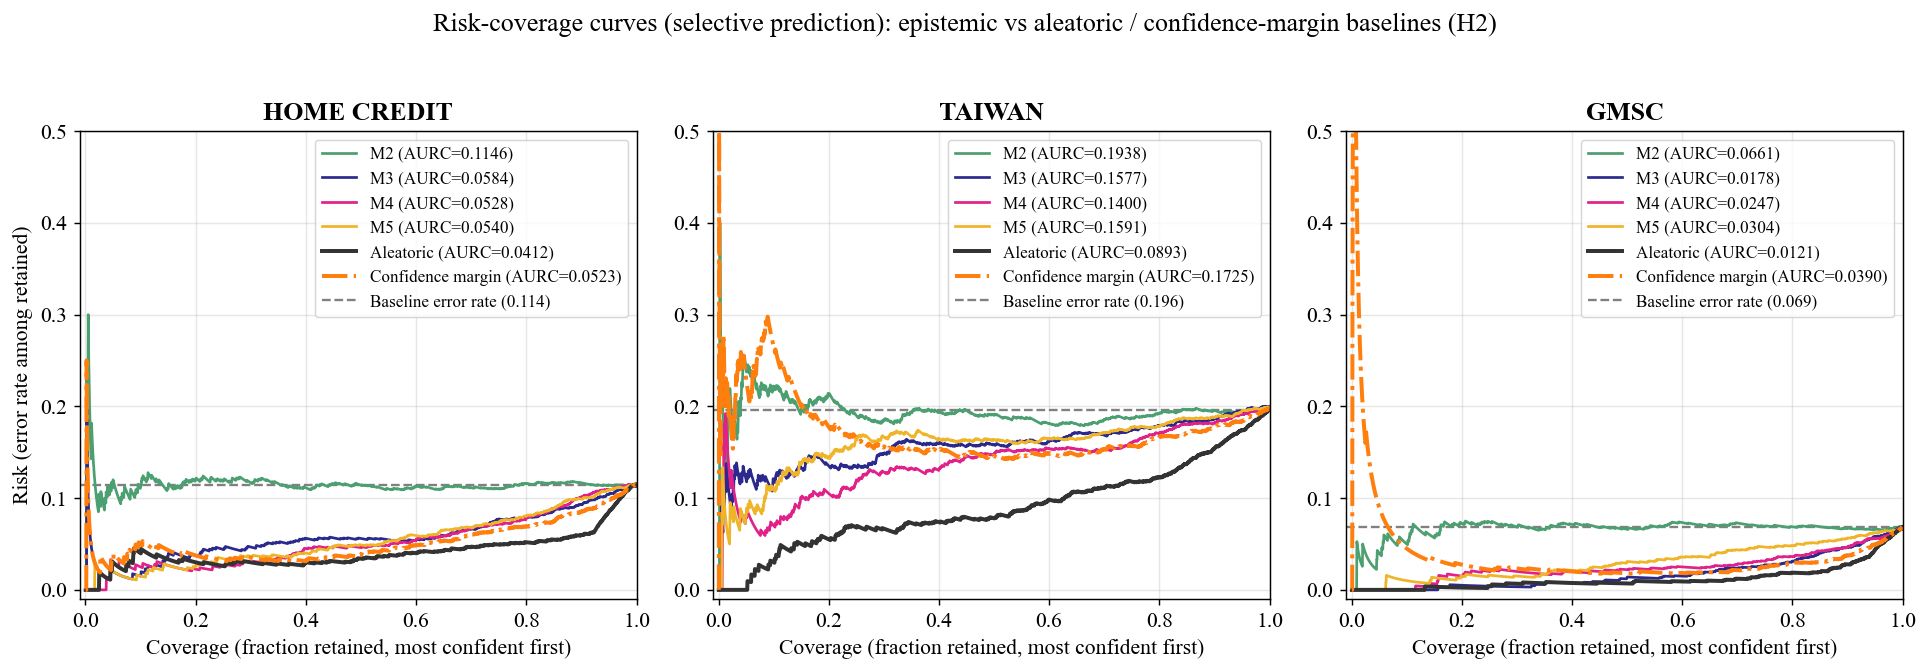


All figures written to ../result/figure


In [30]:
def risk_coverage(order_scores, misclassified):
    """Sort by ascending order_scores (most-confident/least-risky first) and return
    (coverage, risk, AURC) -- same manual-trapezoid recipe as NB6's table4/compute_aurc."""
    order = np.argsort(order_scores)
    sorted_err = np.asarray(misclassified)[order]
    n = len(sorted_err)
    coverage = np.arange(1, n + 1) / n
    risk = np.cumsum(sorted_err) / np.arange(1, n + 1)
    aurc = np.sum((risk[1:] + risk[:-1]) / 2.0 * np.diff(coverage))  # manual trapezoid, numpy-version safe
    return coverage, risk, aurc


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ds in zip(axes, DATASETS):
    baseline = None
    for model in UQ_MODELS:
        path = f"{RAW_NB3_DIR}/{model.lower()}_uncertainty_natural_{ds}.csv"
        if not os.path.exists(path):
            continue
        unc = pd.read_csv(path)
        tau, misclassified = gating_labels(unc)

        coverage, risk, aurc = risk_coverage(unc["epistemic_unc"].values, misclassified.values)
        ax.plot(coverage, risk, color=MODEL_COLOR[model], label=f"{model} (AURC={aurc:.4f})")

        if baseline is None:                     # dùng error rate toàn tập làm mốc nền
            baseline = misclassified.mean()

    # v7 addition (H2): two UQ-free/cheap baselines, computed ONCE per dataset.
    base_unc = None
    for cand in BASELINE_MODEL_CANDIDATES:
        cand_path = f"{RAW_NB3_DIR}/{cand.lower()}_uncertainty_natural_{ds}.csv"
        if os.path.exists(cand_path):
            base_unc = pd.read_csv(cand_path)
            break
    if base_unc is None:
        print(f"  [MISSING] no uncertainty file found for any of {BASELINE_MODEL_CANDIDATES} "
              f"({ds}) -- skipping aleatoric/margin baselines.")
    else:
        b_tau, b_misclassified = gating_labels(base_unc)

        cov_a, risk_a, aurc_a = risk_coverage(base_unc["aleatoric_unc"].values, b_misclassified.values)
        ax.plot(cov_a, risk_a, color="#333333", linewidth=2.2, label=f"Aleatoric (AURC={aurc_a:.4f})")

        margin = -np.abs(base_unc["pred_mean"].values - b_tau)
        cov_m, risk_m, aurc_m = risk_coverage(margin, b_misclassified.values)
        ax.plot(cov_m, risk_m, color="#FF7F0E", linewidth=2.2, linestyle="-.",
                label=f"Confidence margin (AURC={aurc_m:.4f})")

        if baseline is None:
            baseline = b_misclassified.mean()

    if baseline is not None:
        ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.3, zorder=1,
                    label=f"Baseline error rate ({baseline:.3f})")

    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_xlim(-0.01,1)
    ax.set_ylim(-0.01, 0.5)
    ax.set_xlabel("Coverage (fraction retained, most confident first)")
    if ds == "home_credit":
        ax.set_ylabel("Risk (error rate among retained)")
    ax.legend(fontsize=9.5, loc = "upper right")

fig.suptitle("Risk-coverage curves (selective prediction): epistemic vs aleatoric / "
             "confidence-margin baselines (H2)", y=1.03)
fig.tight_layout()
save(fig, "fig12_risk_coverage")

print("\nAll figures written to", OUT_DIR)

## 14. Fig 13 — epistemic magnitude vs gating signal (H3)


--- Tên biểu đồ: fig13_epistemic_magnitude_vs_gating ---
Đã lưu tại: ../result/figure/fig13_epistemic_magnitude_vs_gating.png


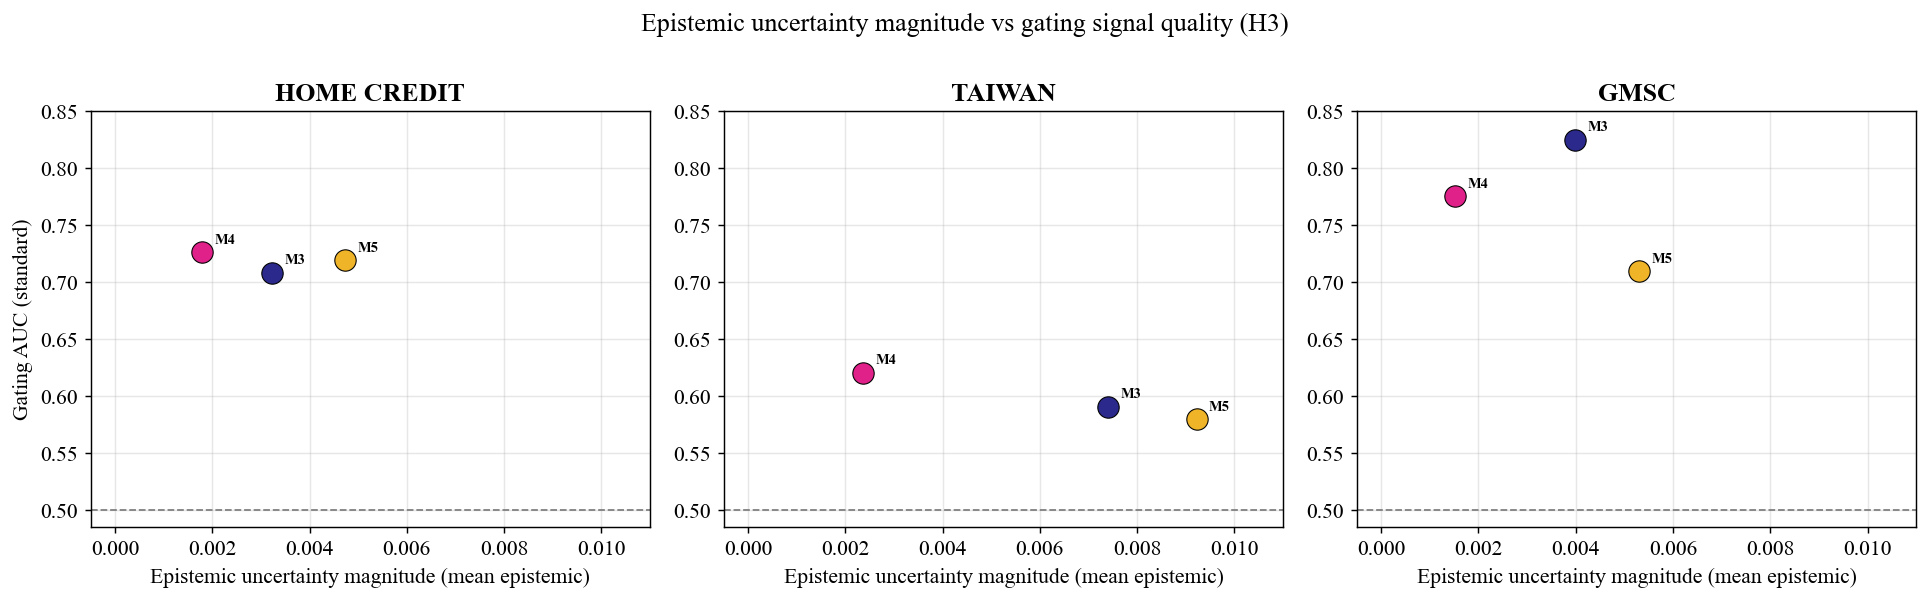

In [31]:
##### fig13: Độ lớn epistemic so với chất lượng tín hiệu định tuyến (H3) #####
epi = table6[table6["Component"] == "epistemic"][["Dataset", "Model", "Mean"]].rename(columns={"Mean": "epi_mean"})
merged = table4.merge(epi, on=["Dataset", "Model"], how="left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, ds in zip(axes, DATASETS):
    sub = merged[merged["Dataset"] == DATASET_LABELS[ds]]
    for model in UQ_MODELS:
        row = sub[sub["Model"] == model]
        if row.empty:
            continue
        x = row["epi_mean"].values[0]
        y = row["Gating_AUC_standard"].values[0]
        if not (np.isfinite(x) and np.isfinite(y)):
            continue   # e.g. M2: Gating_AUC_standard is a structural NaN, see table4 Structural_NA
        ax.scatter(x, y, s=140, color=MODEL_COLOR[model], edgecolor="black",
                   linewidth=0.6, zorder=3, label=model)
        ax.annotate(model, (x, y), textcoords="offset points", xytext=(7, 5),
                    fontsize=8, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, zorder=1)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_xlabel("Epistemic uncertainty magnitude (mean epistemic)")
    if ds == "home_credit":
        ax.set_ylabel("Gating AUC (standard)")
    ax.set_xlim(left=-0.0005, right=0.011)
    ax.set_ylim(0.485, 0.85)

fig.suptitle("Epistemic uncertainty magnitude vs gating signal quality (H3)", y=1)
fig.tight_layout()
save(fig, "fig13_epistemic_magnitude_vs_gating")

## 15. Fig 14 — USFG heatmap before vs after metric calibration


--- Tên biểu đồ: fig14_usfg_before_after_calibration ---
Đã lưu tại: ../result/figure/fig14_usfg_before_after_calibration.png


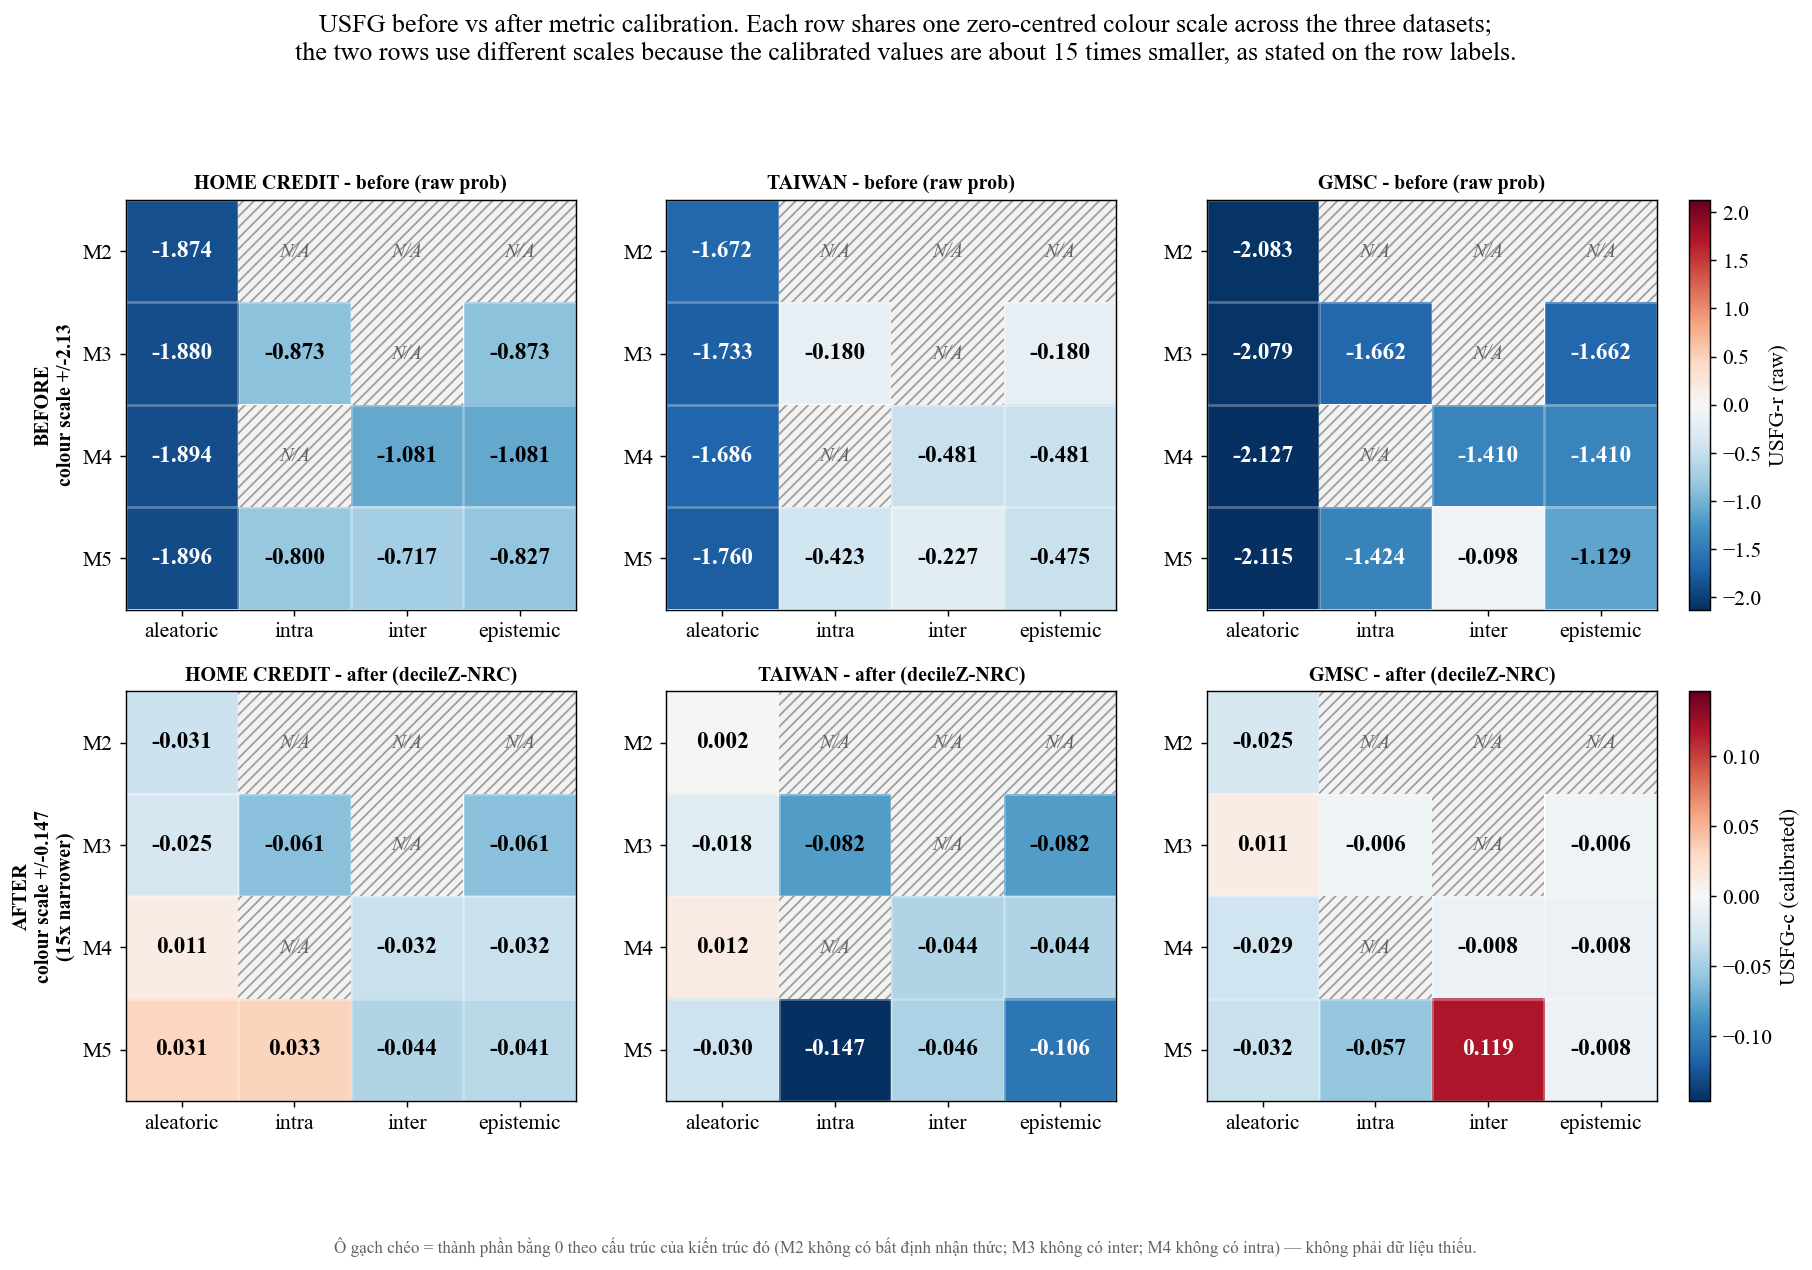

In [32]:
##### fig14: USFG before (raw prob, table9) vs after (decileZ-NRC, table9b) #####
# One shared, zero-centred diverging scale PER ROW (not per panel): the three
# datasets in a row are then directly comparable by colour. The two rows must
# keep separate scales because the calibrated values are ~30x smaller, and that
# ratio is printed on the row label so the difference is stated, not hidden.
shap9 = table9[table9["Method"] == "SHAP"]
shap9b = table9b[table9b["Method"] == "SHAP"] if len(table9b) else pd.DataFrame()
components = ["aleatoric", "intra", "inter", "epistemic"]


def _usfg_matrix(sub, value_col):
    mat = np.full((len(UQ_MODELS), len(components)), np.nan)
    if sub.empty or "Model" not in sub.columns or "Component" not in sub.columns:
        return mat
    for i, model in enumerate(UQ_MODELS):
        for j, comp in enumerate(components):
            r = sub[(sub["Model"] == model) & (sub["Component"] == comp)]
            if not r.empty and value_col in r.columns:
                mat[i, j] = r[value_col].values[0]
    return mat


def _draw_usfg_heatmap(ax, mat, title, vmax):
    """Diverging colormap centred at zero, shared limits passed in by the caller."""
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)

    ax.set_xticks(np.arange(mat.shape[1] + 1) - .5, minor=True)
    ax.set_yticks(np.arange(mat.shape[0] + 1) - .5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.grid(which="major", visible=False)

    ax.set_xticks(range(len(components)))
    ax.set_xticklabels(components)
    ax.set_yticks(range(len(UQ_MODELS)))
    ax.set_yticklabels(UQ_MODELS)
    ax.set_title(title, fontweight="bold", fontsize=11)

    for i in range(len(UQ_MODELS)):
        for j in range(len(components)):
            if not np.isnan(mat[i, j]):
                rgba = im.cmap(im.norm(mat[i, j]))
                lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center",
                        color="white" if lum < 0.5 else "black",
                        fontsize=13, fontweight="bold")

    mark_na_cells(ax, mat, fontsize=11)
    return im


MAT_TOP = [_usfg_matrix(shap9[shap9["Dataset"] == DATASET_LABELS[ds]], "USFG")
           for ds in DATASETS]
MAT_BOT = [_usfg_matrix(shap9b[shap9b["Dataset"] == DATASET_LABELS[ds]]
                        if len(shap9b) else pd.DataFrame(), "USFG_decileZ_NRC")
           for ds in DATASETS]

VMAX_TOP = float(np.nanmax([np.nanmax(np.abs(m)) for m in MAT_TOP]))
VMAX_BOT = float(np.nanmax([np.nanmax(np.abs(m)) for m in MAT_BOT]))
SHRINK = VMAX_TOP / VMAX_BOT if VMAX_BOT > 0 else float("nan")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ds in enumerate(DATASETS):
    im_top = _draw_usfg_heatmap(axes[0, col], MAT_TOP[col],
                                f"{DATASET_LABELS[ds]} - before (raw prob)", VMAX_TOP)
    im_bot = _draw_usfg_heatmap(axes[1, col], MAT_BOT[col],
                                f"{DATASET_LABELS[ds]} - after (decileZ-NRC)", VMAX_BOT)

axes[0, 0].set_ylabel(f"BEFORE\ncolour scale +/-{VMAX_TOP:.2f}",
                      fontweight="bold", fontsize=11)
axes[1, 0].set_ylabel(f"AFTER\ncolour scale +/-{VMAX_BOT:.3f}\n"
                      f"({SHRINK:.0f}x narrower)", fontweight="bold", fontsize=11)

fig.colorbar(im_top, ax=axes[0, :].tolist(), fraction=0.030, pad=0.02,
             label="USFG-r (raw)")
fig.colorbar(im_bot, ax=axes[1, :].tolist(), fraction=0.030, pad=0.02,
             label="USFG-c (calibrated)")

fig.suptitle("USFG before vs after metric calibration. Each row shares one "
             "zero-centred colour scale across the three datasets;\nthe two rows "
             "use different scales because the calibrated values are about "
             f"{SHRINK:.0f} times smaller, as stated on the row labels.", y=1.04)
fig.text(0.5, -0.02, NA_FOOTNOTE, ha="center", fontsize=9.5, color="#616161")
save(fig, "fig14_usfg_before_after_calibration")


## 16. Fig 15 — epistemic dispersion (CV) vs gating signal (H3)


--- Tên biểu đồ: fig15_epistemic_cv_vs_gating ---
Đã lưu tại: ../result/figure/fig15_epistemic_cv_vs_gating.png


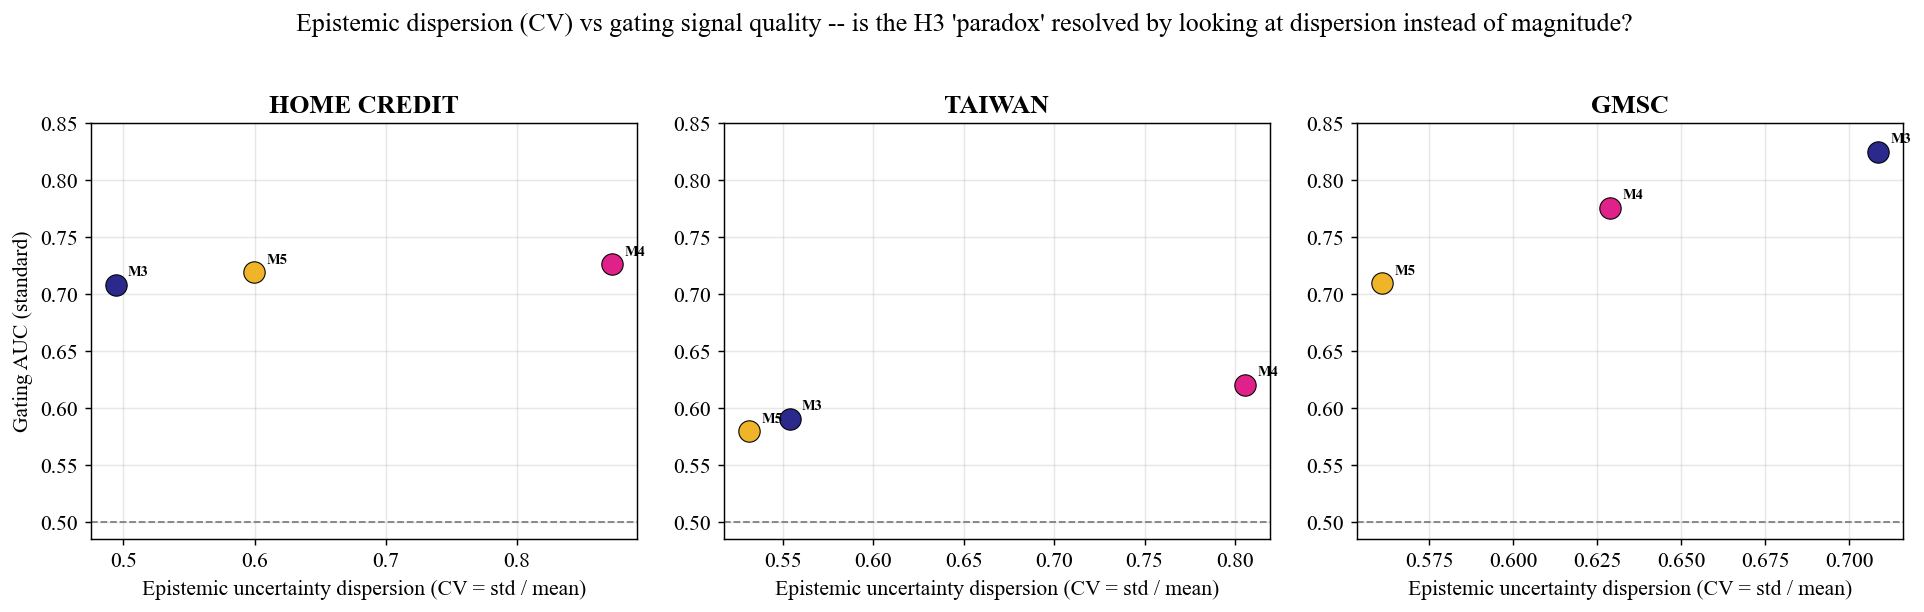

In [33]:
##### fig15: CV_epi (dispersion) vs gating signal quality -- does dispersion resolve the H3 "paradox"? #####
cv_epi = table6[table6["Component"] == "epistemic"][["Dataset", "Model", "CV"]].rename(columns={"CV": "epi_cv"})
merged_cv = table4.merge(cv_epi, on=["Dataset", "Model"], how="left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, ds in zip(axes, DATASETS):
    sub = merged_cv[merged_cv["Dataset"] == DATASET_LABELS[ds]]
    for model in UQ_MODELS:
        row = sub[sub["Model"] == model]
        if row.empty:
            continue
        x = row["epi_cv"].values[0]
        y = row["Gating_AUC_standard"].values[0]
        if not (np.isfinite(x) and np.isfinite(y)):
            continue   # e.g. M2: Gating_AUC_standard is a structural NaN, see table4 Structural_NA
        ax.scatter(x, y, s=140, color=MODEL_COLOR[model], edgecolor="black",
                   linewidth=0.6, zorder=3, label=model)
        ax.annotate(model, (x, y), textcoords="offset points", xytext=(7, 5),
                    fontsize=8, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, zorder=1)
    ax.set_title(DATASET_LABELS[ds], fontweight="bold")
    ax.set_xlabel("Epistemic uncertainty dispersion (CV = std / mean)")
    if ds == "home_credit":
        ax.set_ylabel("Gating AUC (standard)")
    ax.set_ylim(0.485, 0.85)

fig.suptitle("Epistemic dispersion (CV) vs gating signal quality -- is the H3 'paradox' resolved "
             "by looking at dispersion instead of magnitude?", y=1.02)
fig.tight_layout()
save(fig, "fig15_epistemic_cv_vs_gating")

## 17. Fig 16 — per-sample Comp vs base probability (does the base score decide the verdict?)


--- Tên biểu đồ: fig16_per_sample_base_prob_vs_comp ---
Đã lưu tại: ../result/figure/fig16_per_sample_base_prob_vs_comp.png


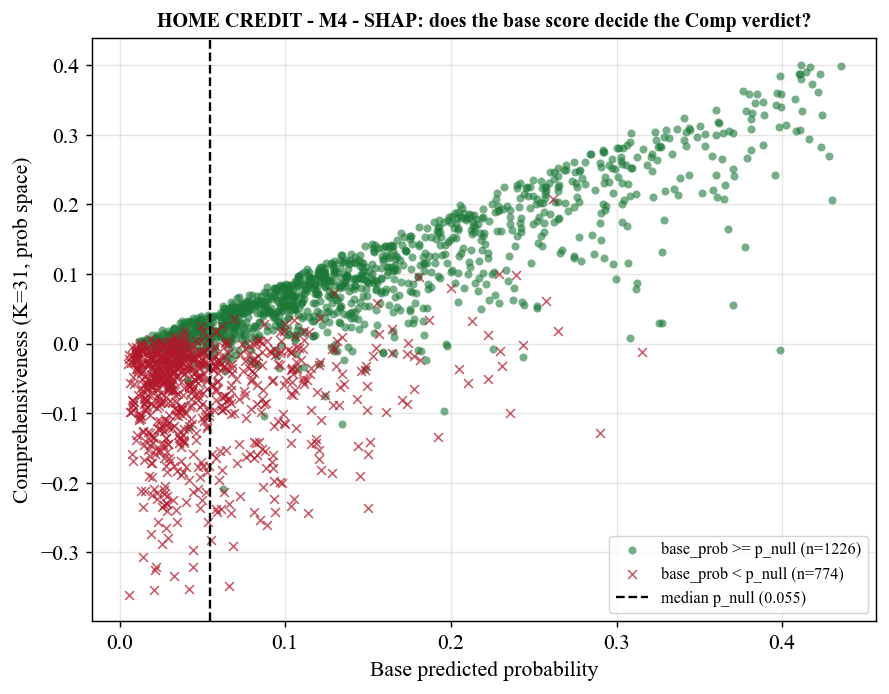

In [34]:
##### fig16: per-sample scatter -- does the base predicted probability alone decide Comp? #####
FIG16_DATASET = "home_credit"
FIG16_MODEL = "M4"
fig16_path = f"{RAW_NB5_DIR}/faithfulness_prob_shap_{FIG16_DATASET}.json"

if not os.path.exists(fig16_path):
    print(f"  [MISSING] {fig16_path} -- skipping fig16 (NB5 has not been re-run with the v7 "
          f"base_probs/p_null_samples schema yet).")
else:
    with open(fig16_path) as f:
        payload16 = json.load(f)
    d16 = payload16.get(FIG16_MODEL, {})
    base_probs16 = np.array(d16.get("base_probs", []))
    p_null16 = np.array(d16.get("p_null_samples", []))
    k_list16 = d16.get("k_list", [])

    if len(base_probs16) == 0 or len(p_null16) == 0 or not k_list16:
        print(f"  [MISSING] {fig16_path} exists but lacks base_probs/p_null_samples for "
              f"{FIG16_MODEL} (old-schema NB5 cache) -- skipping fig16.")
    else:
        mid_k16 = str(k_list16[len(k_list16) // 2])
        comp16 = np.array(d16["comp_samples"][mid_k16])
        n16 = min(len(base_probs16), len(p_null16), len(comp16))
        bp16, pn16, c16 = base_probs16[:n16], p_null16[:n16], comp16[:n16]
        ok16 = np.isfinite(bp16) & np.isfinite(pn16) & np.isfinite(c16)
        bp16, pn16, c16 = bp16[ok16], pn16[ok16], c16[ok16]

        pos16 = (bp16 - pn16) >= 0
        neg16 = ~pos16
        median_pnull16 = float(np.median(pn16))

        fig, ax = plt.subplots(figsize=(7, 5.5))
        ax.scatter(bp16[pos16], c16[pos16], color="#1B7837", marker="o", s=20, alpha=0.6,
                   linewidth=0, label=f"base_prob >= p_null (n={int(pos16.sum())})")
        ax.scatter(bp16[neg16], c16[neg16], color="#B2182B", marker="x", s=24, alpha=0.7,
                   linewidth=0.9, label=f"base_prob < p_null (n={int(neg16.sum())})")
        ax.axvline(median_pnull16, color="black", linestyle="--", linewidth=1.3,
                    label=f"median p_null ({median_pnull16:.3f})")

        ax.set_xlabel("Base predicted probability")
        ax.set_ylabel(f"Comprehensiveness (K={mid_k16}, prob space)")
        ax.set_title(f"{DATASET_LABELS[FIG16_DATASET]} - {FIG16_MODEL} - SHAP: does the base "
                     f"score decide the Comp verdict?", fontweight="bold", fontsize=11)
        ax.legend(fontsize=9, loc="best")
        fig.tight_layout()
        save(fig, "fig16_per_sample_base_prob_vs_comp")